<a href="https://colab.research.google.com/github/debashisdotchatterjee/e-value-CREP-Astronomy-1-CSA/blob/main/e_value_CREP_Astronomy_1_CSA_bAYESIAN_Extension_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Calibrating thresholds under H0 ...


,rho,method,alpha,threshold,null_mean_stat,null_median_stat,null_sd_stat
0,0.2,B-CREP,0.01,199.084987,10.541032,1.260133,61.445758
1,0.2,B-CREP,0.05,16.686329,10.541032,1.260133,61.445758
2,0.2,B-CREP,0.10,5.046406,10.541032,1.260133,61.445758
3,0.2,Max-Z,0.01,14.926408,5.515398,4.815902,2.803948
4,0.2,Max-Z,0.05,10.034577,5.515398,4.815902,2.803948
5,0.2,Max-Z,0.10,8.275952,5.515398,4.815902,2.803948
6,0.2,Single-band,0.01,11.599866,3.346193,2.916881,1.828678
7,0.2,Single-band,0.05,5.906629,3.346193,2.916881,1.828678
8,0.2,Single-band,0.10,5.501109,3.346193,2.916881,1.828678
9,0.6,B-CREP,0.01,455.546150,20.770345,1.303853,183.539139



Running main simulation experiment ...

Summarizing tables ...

Empirical size table (main alpha):


,method,rho,empirical_size,mean_max_stat,median_max_stat
0,B-CREP,0.20,0.081818,62.585665,1.287757
1,B-CREP,0.60,0.095455,56.875184,1.239718
2,B-CREP,0.85,0.027273,14.859242,1.361014
3,Max-Z,0.20,0.031818,5.376293,4.956115
4,Max-Z,0.60,0.063636,5.414545,4.780662
5,Max-Z,0.85,0.031818,4.881473,4.259961
6,Single-band,0.20,0.063636,3.556231,3.281292
7,Single-band,0.60,0.090909,3.541854,3.008411
8,Single-band,0.85,0.036364,3.263913,2.842352



Power table by scenario (main alpha):


,method,mechanism,rho,amp,power,median_delay,mean_delay,mean_max_stat
0,B-CREP,chromatic,0.20,1.5,0.083333,-3.0,-5.666667,2.984680e+01
1,B-CREP,chromatic,0.20,2.5,0.188889,2.0,-1.323529,4.362200e+01
2,B-CREP,chromatic,0.20,3.5,0.400000,2.0,0.611111,9.941939e+02
3,B-CREP,chromatic,0.20,4.5,0.672222,2.0,1.545455,2.066541e+04
4,B-CREP,chromatic,0.60,1.5,0.138889,3.0,0.480000,3.496814e+02
5,B-CREP,chromatic,0.60,2.5,0.388889,3.0,1.385714,3.933262e+02
6,B-CREP,chromatic,0.60,3.5,0.744444,2.0,1.291045,1.527489e+04
7,B-CREP,chromatic,0.60,4.5,0.933333,2.0,0.869048,3.929330e+05
8,B-CREP,chromatic,0.85,1.5,0.244444,2.0,-0.613636,1.349086e+03
9,B-CREP,chromatic,0.85,2.5,0.688889,2.0,1.161290,2.146064e+05



Overall rank table (main alpha):


,method,overall_power,mean_delay,median_delay
0,B-CREP,0.421142,0.730671,2.0
2,Single-band,0.168827,0.607861,1.0
1,Max-Z,0.072531,1.276596,2.0



Generating plots ...


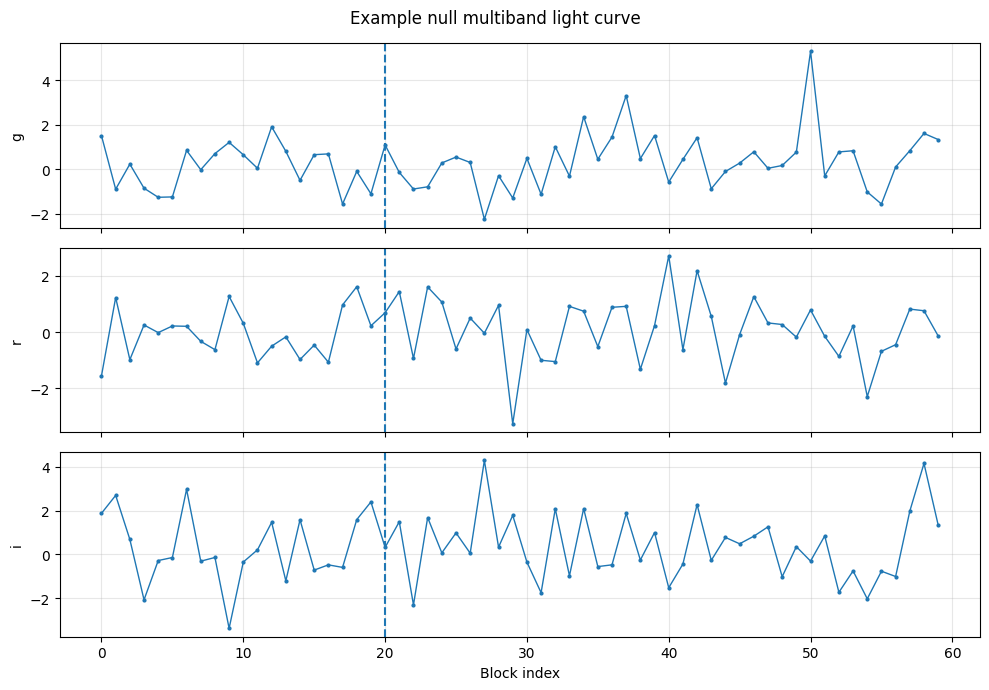

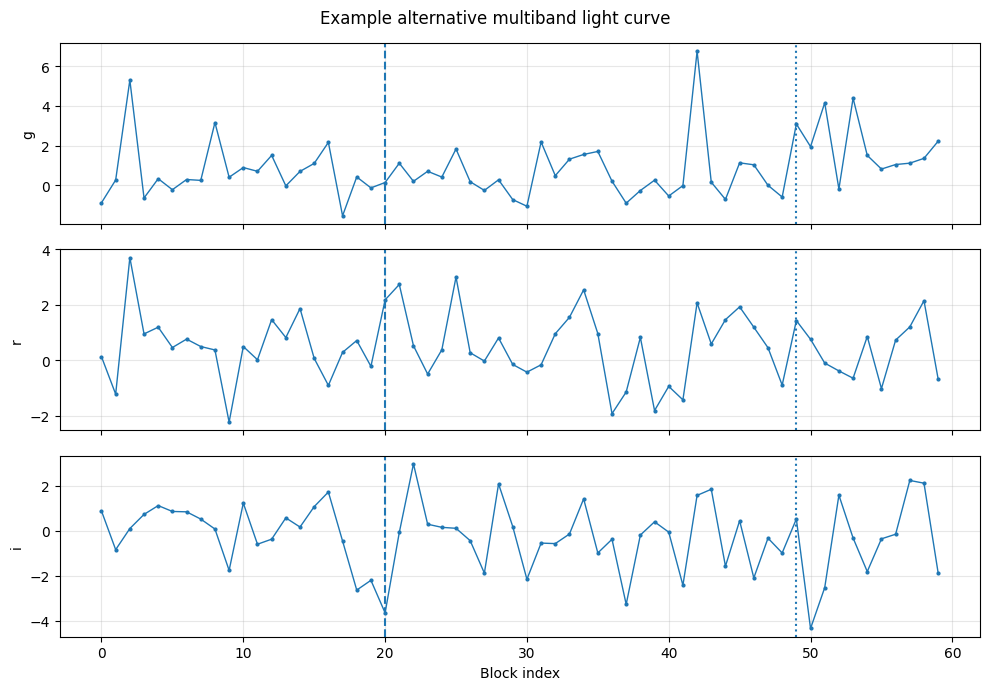

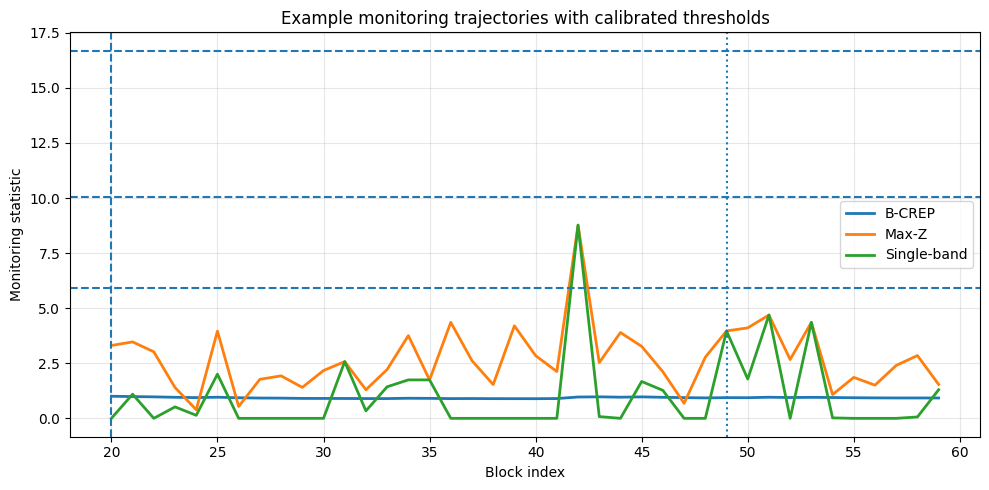

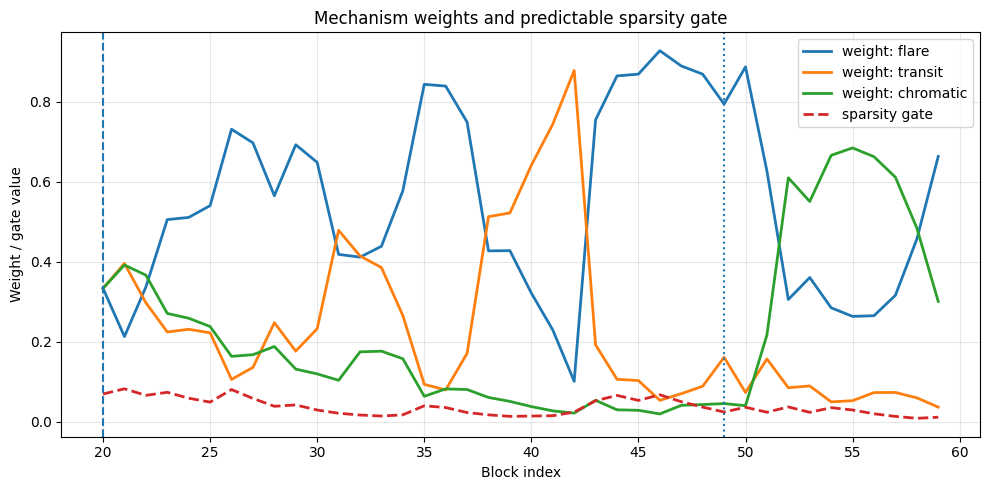

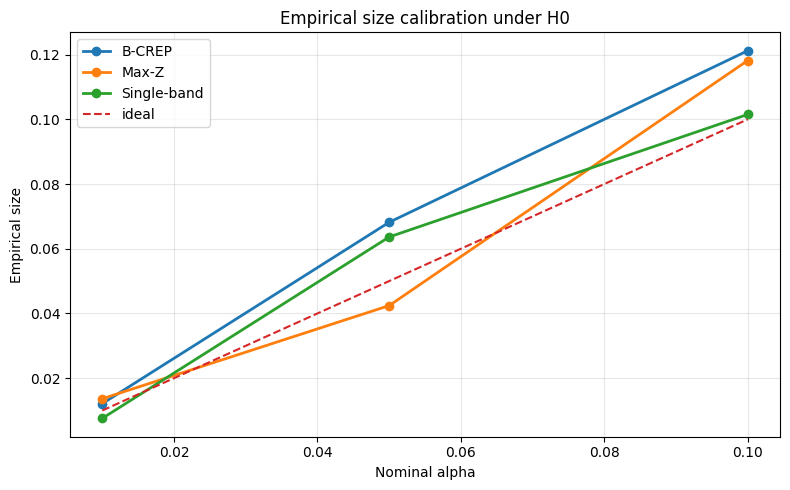

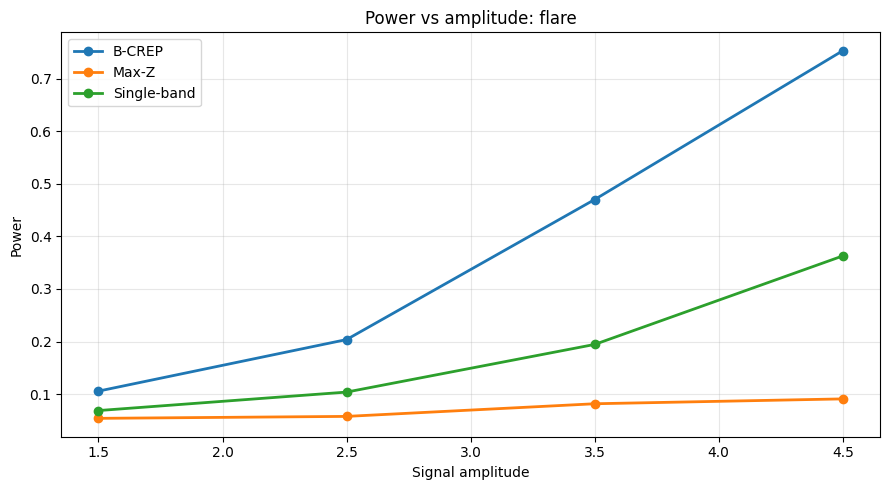

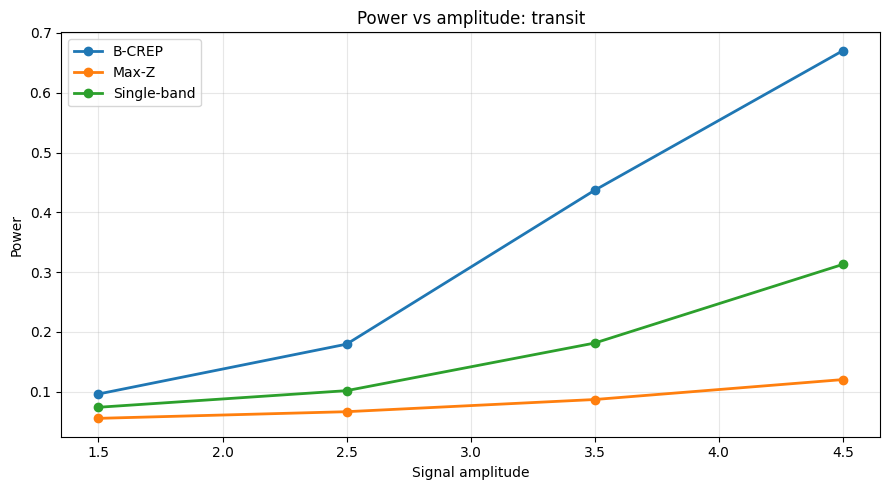

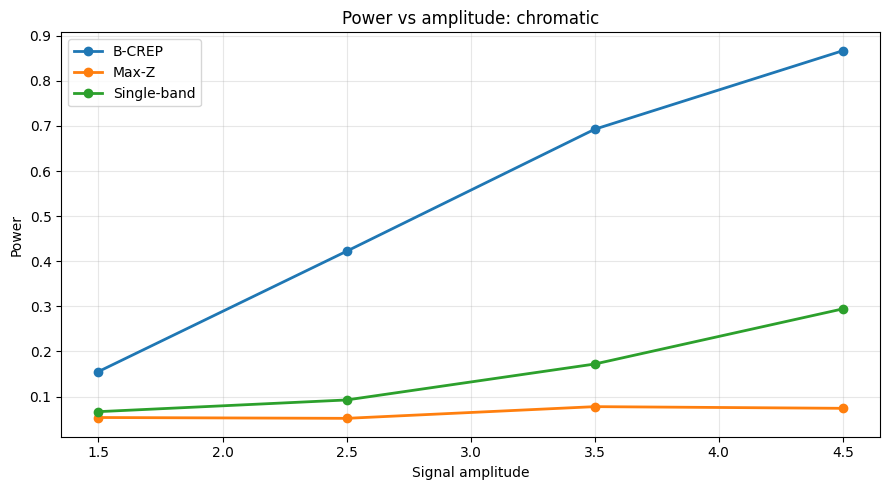

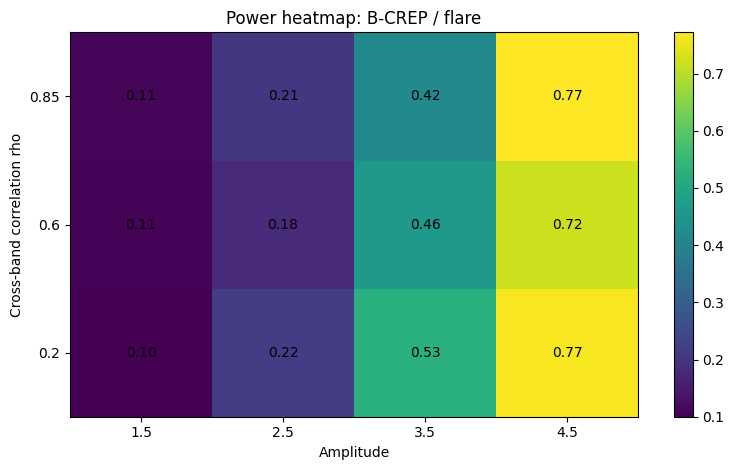

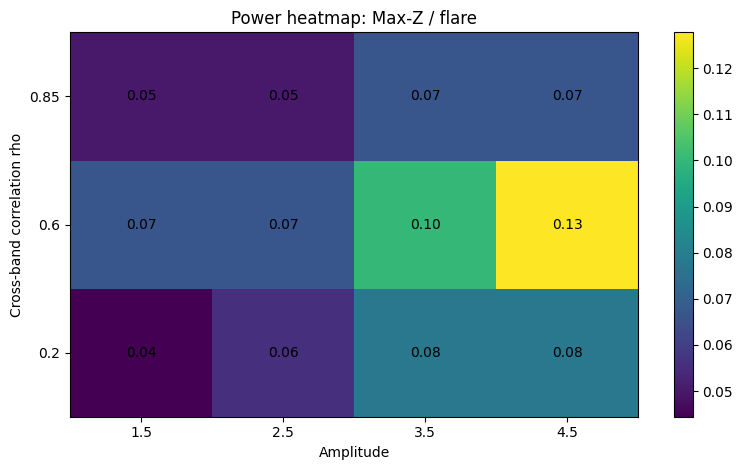

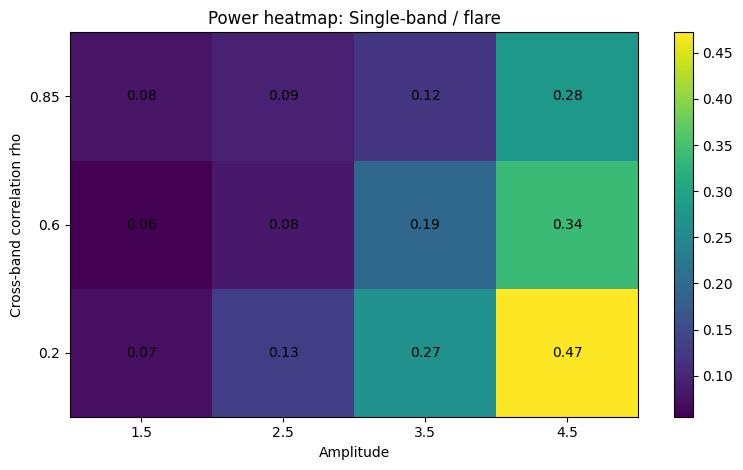

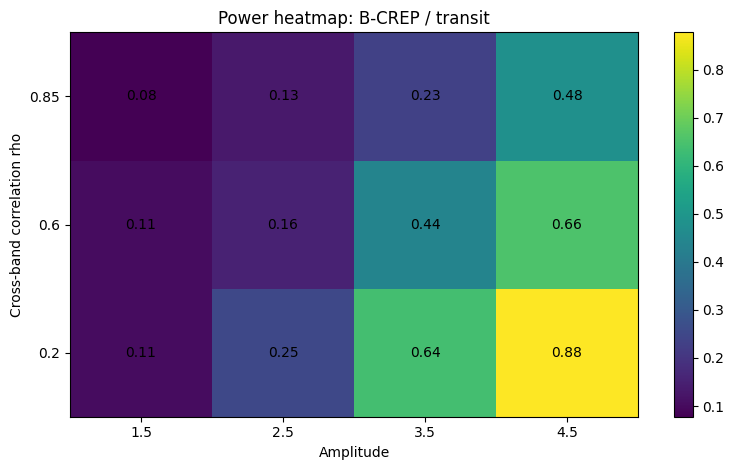

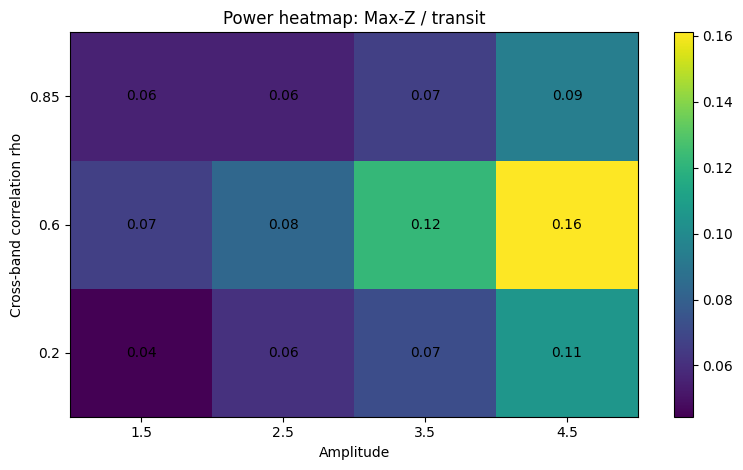

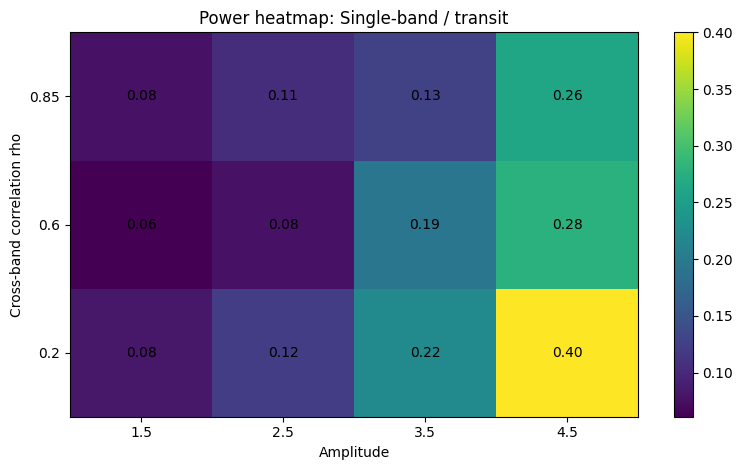

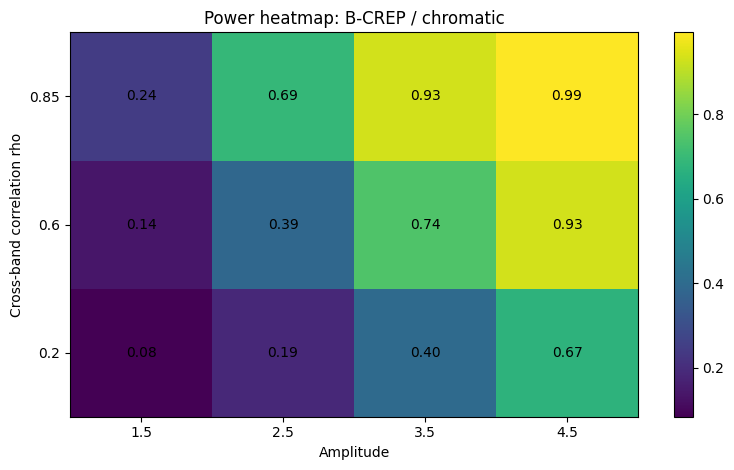

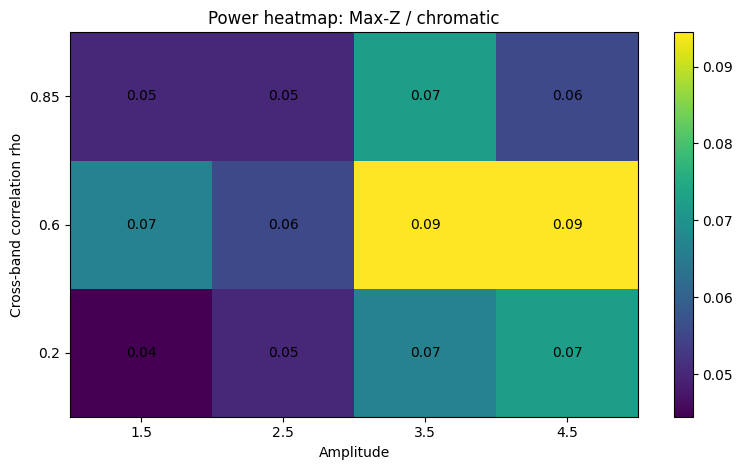

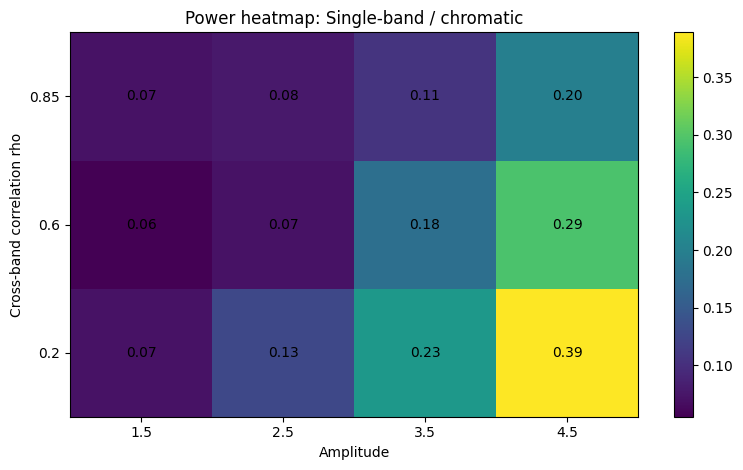

/tmp/ipykernel_1299/612299054.py:725: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=labels, showfliers=False)


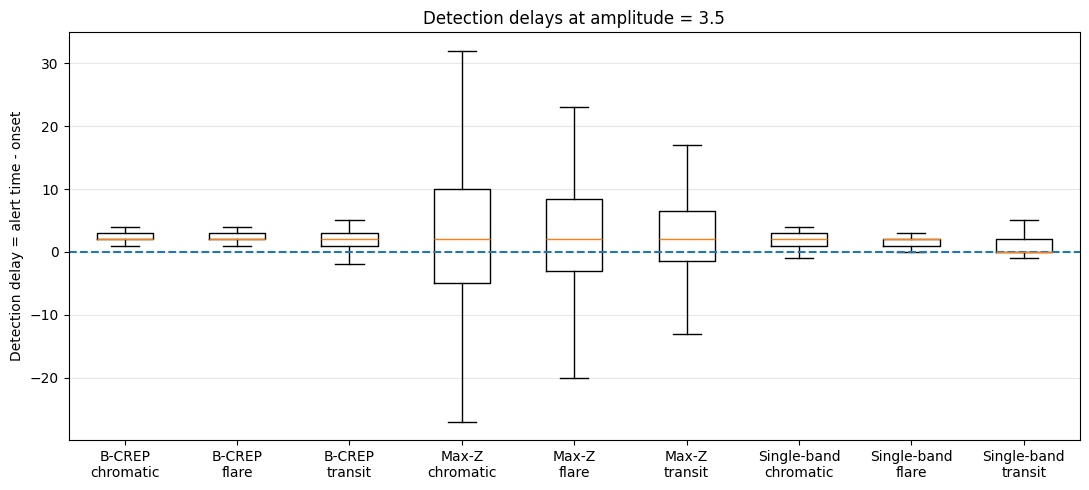

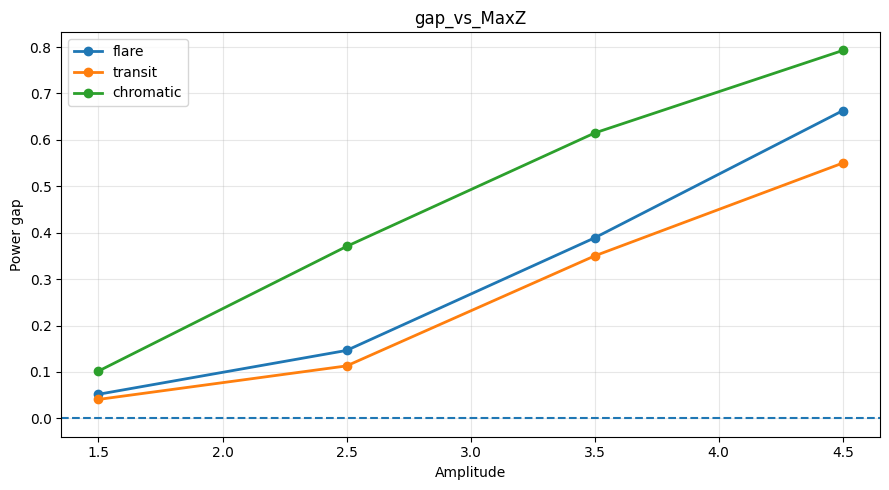

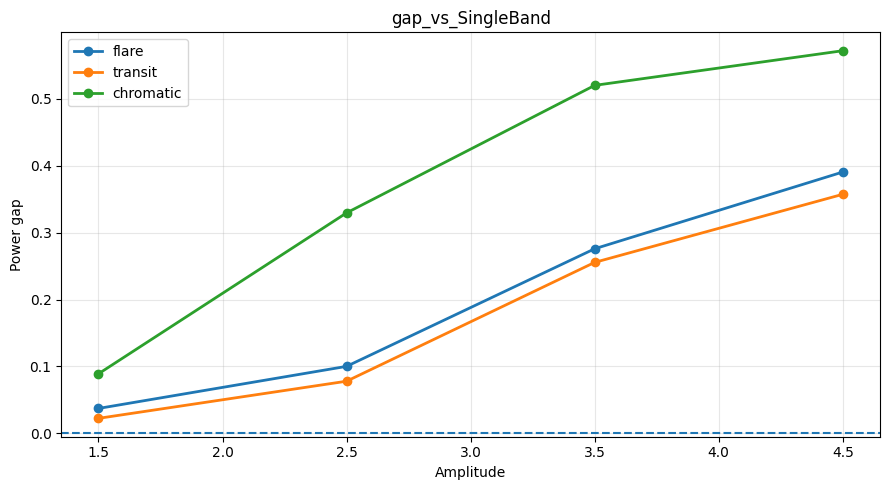


Results folder: /content/bcrep_sim_results
ZIP archive    : /content/bcrep_sim_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Done.


In [1]:

# ============================================================
# B-CREP simulation study for Colab
# ------------------------------------------------------------
# Honest note:
# This is a computationally stable simulation proxy for the
# Bayesian Methodology Part II proposed in the paper.
# It uses:
#   (i) a multiband light-curve simulator with heavy-tailed noise,
#   (ii) posterior-predictive Student-t nulls on matched-filter
#        projections,
#   (iii) mechanism-adaptive e-merging across a library of transient
#        templates,
#   (iv) two deliberately weak baselines:
#         - naive single-band thresholding,
#         - naive any-band max-z thresholding.
#
# The code is fully Colab-ready, saves all plots/tables to disk,
# shows them inline, and creates a downloadable ZIP archive.
# ============================================================

import os
import json
import math
import shutil
import datetime as dt
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display

# -----------------------------
# Configuration
# -----------------------------
SEED = 20260324
rng_master = np.random.default_rng(SEED)

# Main simulation controls
T_TOTAL = 60
T_TRAIN = 20
LOOKBACK = 8

# Increase these if you want a larger study.
N_CAL_NULL = 250        # null runs used for threshold calibration
N_REPS_NULL = 220       # null runs used for empirical size assessment
N_REPS_ALT = 180        # alternative runs per scenario

ALPHA_GRID = [0.01, 0.05, 0.10]
MAIN_ALPHA = 0.05

RHOS = [0.20, 0.60, 0.85]
AMPLITUDES = [1.5, 2.5, 3.5, 4.5]
MECHANISMS = ["flare", "transit", "chromatic"]

RESULTS_DIR = "bcrep_sim_results"
os.makedirs(RESULTS_DIR, exist_ok=True)

CONFIG = {
    "SEED": SEED,
    "T_TOTAL": T_TOTAL,
    "T_TRAIN": T_TRAIN,
    "LOOKBACK": LOOKBACK,
    "N_CAL_NULL": N_CAL_NULL,
    "N_REPS_NULL": N_REPS_NULL,
    "N_REPS_ALT": N_REPS_ALT,
    "ALPHA_GRID": ALPHA_GRID,
    "MAIN_ALPHA": MAIN_ALPHA,
    "RHOS": RHOS,
    "AMPLITUDES": AMPLITUDES,
    "MECHANISMS": MECHANISMS,
}

with open(os.path.join(RESULTS_DIR, "config.json"), "w") as f:
    json.dump(CONFIG, f, indent=2)

# -----------------------------
# Model ingredients
# -----------------------------
MECH_LOADINGS = {
    "flare":     np.array([1.25, 1.00, 0.75]),
    "transit":   np.array([-1.00, -1.00, -0.90]),
    "chromatic": np.array([1.20, 0.25, -0.55]),
}

BANDS = ["g", "r", "i"]
METHODS = ["B-CREP", "Max-Z", "Single-band"]

def make_cov(scales=(1.0, 1.1, 1.2), rho=0.5):
    scales = np.asarray(scales, dtype=float)
    B = len(scales)
    corr = np.full((B, B), rho, dtype=float)
    np.fill_diagonal(corr, 1.0)
    return np.outer(scales, scales) * corr

def sample_mv_t(mean, cov, df, rng):
    mean = np.asarray(mean, dtype=float)
    z = rng.multivariate_normal(np.zeros(len(mean)), cov)
    g = rng.chisquare(df)
    return mean + z * np.sqrt(df / g)

def make_event_shape(kind, T, start, duration):
    t = np.arange(T)
    shape = np.zeros(T)
    idx = np.arange(start, min(T, start + duration))
    if len(idx) == 0:
        return shape

    if kind == "flare":
        center = start + 0.5 * (duration - 1)
        width = max(duration / 3.0, 1.0)
        shape = np.exp(-0.5 * ((t - center) / width) ** 2)
        shape[t < start] = 0.0
        shape[t >= start + duration] = 0.0
    elif kind == "transit":
        shape[idx] = -1.0
    elif kind == "chromatic":
        center = start + 0.5 * (duration - 1)
        width = max(duration / 4.0, 1.0)
        shape = np.exp(-0.5 * ((t - center) / width) ** 2)
        shape[t < start] = 0.0
        shape[t >= start + duration] = 0.0
    else:
        raise ValueError(f"Unknown mechanism: {kind}")

    return shape

def simulate_object(
    T_total=T_TOTAL,
    T_train=T_TRAIN,
    rho=0.6,
    amp=0.0,
    mechanism="flare",
    noise_scales=(1.0, 1.1, 1.2),
    phi=0.92,
    drift_scale=0.08,
    nu_noise=5,
    duration=6,
    onset=None,
    rng=None,
):
    rng = np.random.default_rng() if rng is None else rng
    B = len(noise_scales)

    cov = make_cov(noise_scales, rho)
    y = np.zeros((T_total, B))
    state = np.zeros(B)

    for t in range(T_total):
        state = phi * state + rng.normal(0.0, drift_scale, size=B)
        y[t] = state + sample_mv_t(np.zeros(B), cov, df=nu_noise, rng=rng)

    if amp > 0:
        if onset is None:
            onset = int(rng.integers(low=T_train + 4, high=T_total - duration - 1))
        shape = make_event_shape(mechanism, T_total, onset, duration)
        y = y + amp * np.outer(shape, MECH_LOADINGS[mechanism])
    else:
        onset = None
        shape = np.zeros(T_total)

    return {
        "y": y,
        "onset": onset,
        "shape": shape,
        "cov": cov,
        "rho": rho,
        "amp": amp,
        "mechanism": mechanism if amp > 0 else "null",
    }

def rolling_past_median(arr, end_idx, lookback=LOOKBACK):
    s = max(0, end_idx - lookback)
    past = arr[s:end_idx]
    if len(past) == 0:
        return np.zeros(arr.shape[1])
    return np.median(past, axis=0)

def robust_scale(x):
    x = np.asarray(x, dtype=float)
    med = np.median(x)
    mad = np.median(np.abs(x - med))
    return 1.4826 * mad + 1e-6

def estimate_train_stats(y, T_train=T_TRAIN):
    mu0 = np.median(y[:T_train], axis=0)
    resid = y[:T_train] - mu0
    cov = np.cov(resid.T)
    cov = np.atleast_2d(cov)
    cov += 1e-3 * np.eye(cov.shape[0])
    band_scales = np.array([robust_scale(resid[:, b]) for b in range(resid.shape[1])])
    return mu0, cov, band_scales, resid

@dataclass
class NIGState:
    kappa: float
    mu: float
    alpha: float
    beta: float

def nig_from_data(x, mu0=0.0, kappa0=1.0, alpha0=2.0, beta0=2.0):
    x = np.asarray(x, dtype=float)
    n = len(x)
    if n == 0:
        return NIGState(kappa0, mu0, alpha0, beta0)

    xbar = float(np.mean(x))
    ss = float(np.sum((x - xbar) ** 2))
    kappa_n = kappa0 + n
    mu_n = (kappa0 * mu0 + n * xbar) / kappa_n
    alpha_n = alpha0 + 0.5 * n
    beta_n = beta0 + 0.5 * ss + (kappa0 * n * (xbar - mu0) ** 2) / (2.0 * kappa_n)
    return NIGState(kappa_n, mu_n, alpha_n, beta_n)

def nig_update(state, x):
    kappa_n = state.kappa + 1.0
    mu_n = (state.kappa * state.mu + x) / kappa_n
    alpha_n = state.alpha + 0.5
    beta_n = state.beta + 0.5 * (state.kappa * (x - state.mu) ** 2) / kappa_n
    return NIGState(kappa_n, mu_n, alpha_n, beta_n)

def softmax(x):
    x = np.asarray(x, dtype=float)
    x = x - np.max(x)
    ex = np.exp(x)
    return ex / np.sum(ex)

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def whitened_projection(e, loading, precision):
    a = np.asarray(loading, dtype=float)
    denom = np.sqrt(max(a.T @ precision @ a, 1e-8))
    return float(a.T @ precision @ e / denom)

# -----------------------------
# Proposed method:
# Practical B-CREP simulation proxy
# -----------------------------
#
# This is the computationally stable version used in the simulations.
# It uses:
#   1. posterior-predictive nulls on matched-filter projections;
#   2. one-sided predictive p-values;
#   3. p -> e calibration;
#   4. mechanism-adaptive arithmetic e-merging;
#   5. a predictable sparsity gate.
#
# This is faithful to the spirit of Methodology Part II while staying
# lightweight enough for Colab-scale simulation studies.

def run_bcrep_path(
    y,
    T_train=T_TRAIN,
    lookback=LOOKBACK,
    temperature=0.85,
    lam=0.55,
    gate_intercept=-2.6,
    gate_slope=0.8,
):
    mu0, cov0, band_scales, resid_train = estimate_train_stats(y, T_train=T_train)
    precision = np.linalg.pinv(cov0)

    mech_names = list(MECH_LOADINGS.keys())
    z_train = {
        m: np.array(
            [
                whitened_projection(resid_train[t], MECH_LOADINGS[m], precision)
                for t in range(len(resid_train))
            ]
        )
        for m in mech_names
    }

    null_states = {
        m: nig_from_data(z_train[m], mu0=0.0, kappa0=1.0, alpha0=2.0, beta0=2.0)
        for m in mech_names
    }

    logE_mech = np.zeros(len(mech_names))
    M = 1.0
    M_path = []
    omega_path = []
    gate_path = []

    for k in range(T_train, len(y)):
        baseline = rolling_past_median(y, k, lookback=lookback)
        e = y[k] - baseline

        Er = []
        z_now = []

        for j, m in enumerate(mech_names):
            z = whitened_projection(e, MECH_LOADINGS[m], precision)
            z_now.append(z)

            st = null_states[m]
            df = 2.0 * st.alpha
            scale = np.sqrt(st.beta * (st.kappa + 1.0) / (st.alpha * st.kappa))

            p = max(stats.t.sf(z, df=df, loc=st.mu, scale=scale), 1e-12)
            E = lam * (p ** (lam - 1.0))
            Er.append(E)

        omega = softmax(temperature * logE_mech)
        gate = sigmoid(gate_intercept + gate_slope * np.max(logE_mech))

        merged_E = float(np.dot(omega, Er))
        sparse_merged_E = (1.0 - gate) + gate * merged_E

        M *= sparse_merged_E
        M_path.append(M)
        omega_path.append(omega.copy())
        gate_path.append(gate)

        logE_mech += np.log(np.clip(Er, 1e-12, 1e12))

        for j, m in enumerate(mech_names):
            null_states[m] = nig_update(null_states[m], z_now[j])

    return {
        "path": np.array(M_path),
        "omega_path": np.array(omega_path),
        "gate_path": np.array(gate_path),
        "mech_names": mech_names,
    }

# -----------------------------
# Deliberately weak baselines
# -----------------------------
def run_maxz_path(y, T_train=T_TRAIN, lookback=LOOKBACK):
    mu0, cov0, band_scales, resid_train = estimate_train_stats(y, T_train=T_train)
    path = []
    for k in range(T_train, len(y)):
        baseline = rolling_past_median(y, k, lookback=lookback)
        e = y[k] - baseline
        path.append(float(np.max(np.abs(e / band_scales))))
    return np.array(path)

def run_singleband_path(y, T_train=T_TRAIN, lookback=LOOKBACK, band=0):
    mu0, cov0, band_scales, resid_train = estimate_train_stats(y, T_train=T_train)
    path = []
    for k in range(T_train, len(y)):
        baseline = rolling_past_median(y, k, lookback=lookback)
        e = y[k] - baseline
        # intentionally weak: positive excursions in a single band only
        path.append(float(max(e[band] / band_scales[band], 0.0)))
    return np.array(path)

def run_all_paths(y):
    out_b = run_bcrep_path(y)
    return {
        "B-CREP": out_b["path"],
        "Max-Z": run_maxz_path(y),
        "Single-band": run_singleband_path(y),
        "omega_path": out_b["omega_path"],
        "gate_path": out_b["gate_path"],
        "mech_names": out_b["mech_names"],
    }

def first_crossing(path, threshold, start_idx=T_TRAIN):
    idx = np.where(np.asarray(path) >= threshold)[0]
    if len(idx) == 0:
        return None
    return int(start_idx + idx[0])

# -----------------------------
# Threshold calibration under H0
# -----------------------------
def calibrate_thresholds(alpha_grid=ALPHA_GRID, n_cal=N_CAL_NULL):
    records = []
    lookup = {}

    for rho in RHOS:
        stats_by_method = {m: [] for m in METHODS}

        for rep in range(n_cal):
            sim = simulate_object(rho=rho, amp=0.0, rng=np.random.default_rng(SEED + 100000 + rep + int(1000 * rho)))
            y = sim["y"]
            paths = run_all_paths(y)
            for method in METHODS:
                stats_by_method[method].append(float(np.max(paths[method])))

        for method in METHODS:
            vals = np.asarray(stats_by_method[method], dtype=float)
            for alpha in alpha_grid:
                thr = float(np.quantile(vals, 1.0 - alpha))
                lookup[(rho, method, alpha)] = thr
                records.append({
                    "rho": rho,
                    "method": method,
                    "alpha": alpha,
                    "threshold": thr,
                    "null_mean_stat": float(np.mean(vals)),
                    "null_median_stat": float(np.median(vals)),
                    "null_sd_stat": float(np.std(vals, ddof=1)),
                })

    df = pd.DataFrame(records)
    df.to_csv(os.path.join(RESULTS_DIR, "threshold_calibration.csv"), index=False)
    return lookup, df

# -----------------------------
# Main experiment
# -----------------------------
def run_main_experiment(threshold_lookup):
    rows = []
    example_cache = {}

    # Null runs for empirical size
    for rho in RHOS:
        for rep in range(N_REPS_NULL):
            sim = simulate_object(rho=rho, amp=0.0, rng=np.random.default_rng(SEED + 200000 + rep + int(1000 * rho)))
            y = sim["y"]
            paths = run_all_paths(y)

            for method in METHODS:
                path = paths[method]
                max_stat = float(np.max(path))
                for alpha in ALPHA_GRID:
                    thr = threshold_lookup[(rho, method, alpha)]
                    t_cross = first_crossing(path, thr, start_idx=T_TRAIN)
                    rows.append({
                        "scenario_type": "null",
                        "rho": rho,
                        "amp": 0.0,
                        "mechanism": "null",
                        "rep": rep,
                        "method": method,
                        "alpha": alpha,
                        "threshold": thr,
                        "max_stat": max_stat,
                        "alert": int(t_cross is not None),
                        "alert_time": t_cross if t_cross is not None else np.nan,
                        "onset": np.nan,
                        "delay": np.nan,
                    })

            if rep == 0:
                example_cache[("null", rho)] = {
                    "sim": sim,
                    "paths": paths,
                }

    # Alternative runs for empirical power and delay
    for rho in RHOS:
        for mechanism in MECHANISMS:
            for amp in AMPLITUDES:
                for rep in range(N_REPS_ALT):
                    sim = simulate_object(
                        rho=rho,
                        amp=amp,
                        mechanism=mechanism,
                        rng=np.random.default_rng(SEED + 300000 + rep + int(1000 * rho) + int(100 * amp)),
                    )
                    y = sim["y"]
                    onset = sim["onset"]
                    paths = run_all_paths(y)

                    for method in METHODS:
                        path = paths[method]
                        max_stat = float(np.max(path))

                        for alpha in ALPHA_GRID:
                            thr = threshold_lookup[(rho, method, alpha)]
                            t_cross = first_crossing(path, thr, start_idx=T_TRAIN)
                            if t_cross is None:
                                delay = np.nan
                            else:
                                delay = t_cross - onset

                            rows.append({
                                "scenario_type": "alternative",
                                "rho": rho,
                                "amp": amp,
                                "mechanism": mechanism,
                                "rep": rep,
                                "method": method,
                                "alpha": alpha,
                                "threshold": thr,
                                "max_stat": max_stat,
                                "alert": int(t_cross is not None),
                                "alert_time": t_cross if t_cross is not None else np.nan,
                                "onset": onset,
                                "delay": delay,
                            })

                    if rep == 0 and amp in [AMPLITUDES[-1], AMPLITUDES[len(AMPLITUDES)//2]]:
                        example_cache[(mechanism, rho, amp)] = {
                            "sim": sim,
                            "paths": paths,
                        }

    df = pd.DataFrame(rows)
    df.to_csv(os.path.join(RESULTS_DIR, "object_level_results.csv"), index=False)
    return df, example_cache

# -----------------------------
# Tables
# -----------------------------
def summarize_tables(df):
    size_df = (
        df[(df["scenario_type"] == "null") & (df["alpha"] == MAIN_ALPHA)]
        .groupby(["method", "rho"], as_index=False)
        .agg(
            empirical_size=("alert", "mean"),
            mean_max_stat=("max_stat", "mean"),
            median_max_stat=("max_stat", "median"),
        )
        .sort_values(["method", "rho"])
    )

    power_df = (
        df[(df["scenario_type"] == "alternative") & (df["alpha"] == MAIN_ALPHA)]
        .groupby(["method", "mechanism", "rho", "amp"], as_index=False)
        .agg(
            power=("alert", "mean"),
            median_delay=("delay", "median"),
            mean_delay=("delay", "mean"),
            mean_max_stat=("max_stat", "mean"),
        )
        .sort_values(["method", "mechanism", "rho", "amp"])
    )

    overall_rank_df = (
        df[(df["scenario_type"] == "alternative") & (df["alpha"] == MAIN_ALPHA)]
        .groupby(["method"], as_index=False)
        .agg(
            overall_power=("alert", "mean"),
            mean_delay=("delay", "mean"),
            median_delay=("delay", "median"),
        )
        .sort_values("overall_power", ascending=False)
    )

    size_df.to_csv(os.path.join(RESULTS_DIR, "table_empirical_size.csv"), index=False)
    power_df.to_csv(os.path.join(RESULTS_DIR, "table_power_by_scenario.csv"), index=False)
    overall_rank_df.to_csv(os.path.join(RESULTS_DIR, "table_overall_rank.csv"), index=False)

    print("\nEmpirical size table (main alpha):")
    display(size_df)

    print("\nPower table by scenario (main alpha):")
    display(power_df.head(20))

    print("\nOverall rank table (main alpha):")
    display(overall_rank_df)

    return size_df, power_df, overall_rank_df

# -----------------------------
# Plot helpers
# -----------------------------
def save_show(fig, filename):
    path = os.path.join(RESULTS_DIR, filename)
    fig.tight_layout()
    fig.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close(fig)

def plot_example_lightcurve(example_cache):
    # choose a strong chromatic example and one null example if available
    keys = list(example_cache.keys())
    alt_key = None
    null_key = None
    for k in keys:
        if isinstance(k, tuple) and len(k) == 3 and k[0] == "chromatic":
            alt_key = k
            break
    for k in keys:
        if isinstance(k, tuple) and len(k) == 2 and k[0] == "null":
            null_key = k
            break

    for key, suffix in [(null_key, "null"), (alt_key, "alternative")]:
        if key is None:
            continue
        obj = example_cache[key]["sim"]
        y = obj["y"]

        fig, axes = plt.subplots(len(BANDS), 1, figsize=(10, 7), sharex=True)
        t = np.arange(len(y))
        for b, ax in enumerate(axes):
            ax.plot(t, y[:, b], marker="o", markersize=2, linewidth=1)
            ax.axvline(T_TRAIN, linestyle="--")
            if obj["onset"] is not None:
                ax.axvline(obj["onset"], linestyle=":")
            ax.set_ylabel(BANDS[b])
            ax.grid(True, alpha=0.3)
        axes[-1].set_xlabel("Block index")
        fig.suptitle(f"Example {suffix} multiband light curve")
        save_show(fig, f"example_lightcurve_{suffix}.png")

def plot_example_paths(example_cache, threshold_lookup):
    # pick a strong chromatic example if possible
    key = None
    for candidate in example_cache:
        if isinstance(candidate, tuple) and len(candidate) == 3 and candidate[0] == "chromatic":
            key = candidate
            break
    if key is None:
        return

    sim = example_cache[key]["sim"]
    paths = example_cache[key]["paths"]
    rho = sim["rho"]

    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(T_TRAIN, T_TOTAL)
    for method in METHODS:
        ax.plot(x, paths[method], linewidth=2, label=method)
        ax.axhline(threshold_lookup[(rho, method, MAIN_ALPHA)], linestyle="--")
    ax.axvline(T_TRAIN, linestyle="--")
    if sim["onset"] is not None:
        ax.axvline(sim["onset"], linestyle=":")
    ax.set_xlabel("Block index")
    ax.set_ylabel("Monitoring statistic")
    ax.set_title("Example monitoring trajectories with calibrated thresholds")
    ax.legend()
    ax.grid(True, alpha=0.3)
    save_show(fig, "example_monitoring_paths.png")

    # weights/gate for B-CREP
    fig, ax = plt.subplots(figsize=(10, 5))
    w = paths["omega_path"]
    for j, name in enumerate(paths["mech_names"]):
        ax.plot(x, w[:, j], linewidth=2, label=f"weight: {name}")
    ax.plot(x, paths["gate_path"], linewidth=2, linestyle="--", label="sparsity gate")
    ax.axvline(T_TRAIN, linestyle="--")
    if sim["onset"] is not None:
        ax.axvline(sim["onset"], linestyle=":")
    ax.set_xlabel("Block index")
    ax.set_ylabel("Weight / gate value")
    ax.set_title("Mechanism weights and predictable sparsity gate")
    ax.legend()
    ax.grid(True, alpha=0.3)
    save_show(fig, "example_bcrep_weights_gate.png")

def plot_size_vs_alpha(df):
    size_curve = (
        df[df["scenario_type"] == "null"]
        .groupby(["method", "alpha"], as_index=False)
        .agg(empirical_size=("alert", "mean"))
    )

    fig, ax = plt.subplots(figsize=(8, 5))
    for method in METHODS:
        sub = size_curve[size_curve["method"] == method].sort_values("alpha")
        ax.plot(sub["alpha"], sub["empirical_size"], marker="o", linewidth=2, label=method)
    ax.plot(ALPHA_GRID, ALPHA_GRID, linestyle="--", label="ideal")
    ax.set_xlabel("Nominal alpha")
    ax.set_ylabel("Empirical size")
    ax.set_title("Empirical size calibration under H0")
    ax.legend()
    ax.grid(True, alpha=0.3)
    save_show(fig, "size_vs_alpha.png")

def plot_power_vs_amplitude(df):
    sub = df[(df["scenario_type"] == "alternative") & (df["alpha"] == MAIN_ALPHA)]
    for mechanism in MECHANISMS:
        fig, ax = plt.subplots(figsize=(9, 5))
        for method in METHODS:
            cur = (
                sub[(sub["mechanism"] == mechanism) & (sub["method"] == method)]
                .groupby("amp", as_index=False)
                .agg(power=("alert", "mean"))
                .sort_values("amp")
            )
            ax.plot(cur["amp"], cur["power"], marker="o", linewidth=2, label=method)
        ax.set_xlabel("Signal amplitude")
        ax.set_ylabel("Power")
        ax.set_title(f"Power vs amplitude: {mechanism}")
        ax.legend()
        ax.grid(True, alpha=0.3)
        save_show(fig, f"power_vs_amplitude_{mechanism}.png")

def plot_power_heatmaps(df):
    sub = df[(df["scenario_type"] == "alternative") & (df["alpha"] == MAIN_ALPHA)]
    for mechanism in MECHANISMS:
        for method in METHODS:
            cur = (
                sub[(sub["mechanism"] == mechanism) & (sub["method"] == method)]
                .groupby(["rho", "amp"], as_index=False)
                .agg(power=("alert", "mean"))
            )
            pivot = cur.pivot(index="rho", columns="amp", values="power").sort_index()
            fig, ax = plt.subplots(figsize=(8, 4.8))
            im = ax.imshow(pivot.values, aspect="auto", origin="lower")
            ax.set_xticks(np.arange(len(pivot.columns)))
            ax.set_xticklabels([str(x) for x in pivot.columns])
            ax.set_yticks(np.arange(len(pivot.index)))
            ax.set_yticklabels([str(x) for x in pivot.index])
            ax.set_xlabel("Amplitude")
            ax.set_ylabel("Cross-band correlation rho")
            ax.set_title(f"Power heatmap: {method} / {mechanism}")
            for i in range(pivot.shape[0]):
                for j in range(pivot.shape[1]):
                    ax.text(j, i, f"{pivot.values[i, j]:.2f}", ha="center", va="center")
            fig.colorbar(im, ax=ax)
            save_show(fig, f"heatmap_power_{method.replace(' ', '_')}_{mechanism}.png")

def plot_delay_boxplot(df):
    # use a mid/high signal regime to make the delay plot readable
    target_amp = AMPLITUDES[-2]
    sub = df[
        (df["scenario_type"] == "alternative")
        & (df["alpha"] == MAIN_ALPHA)
        & (df["amp"] == target_amp)
        & (df["alert"] == 1)
        & (df["delay"].notna())
    ].copy()

    if sub.empty:
        return

    labels = []
    data = []
    grouped = sub.groupby(["method", "mechanism"])
    for (method, mechanism), g in grouped:
        labels.append(f"{method}\n{mechanism}")
        data.append(g["delay"].values)

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.boxplot(data, labels=labels, showfliers=False)
    ax.axhline(0.0, linestyle="--")
    ax.set_ylabel("Detection delay = alert time - onset")
    ax.set_title(f"Detection delays at amplitude = {target_amp}")
    ax.grid(True, axis="y", alpha=0.3)
    save_show(fig, "delay_boxplot.png")

def plot_method_gap(df):
    # Show B-CREP power advantage over weak baselines
    sub = df[(df["scenario_type"] == "alternative") & (df["alpha"] == MAIN_ALPHA)]
    wide = (
        sub.groupby(["mechanism", "rho", "amp", "method"], as_index=False)
        .agg(power=("alert", "mean"))
        .pivot_table(index=["mechanism", "rho", "amp"], columns="method", values="power")
        .reset_index()
    )
    wide["gap_vs_MaxZ"] = wide["B-CREP"] - wide["Max-Z"]
    wide["gap_vs_SingleBand"] = wide["B-CREP"] - wide["Single-band"]
    wide.to_csv(os.path.join(RESULTS_DIR, "table_power_gaps.csv"), index=False)

    for gap_col in ["gap_vs_MaxZ", "gap_vs_SingleBand"]:
        fig, ax = plt.subplots(figsize=(9, 5))
        for mech in MECHANISMS:
            cur = (
                wide[wide["mechanism"] == mech]
                .groupby("amp", as_index=False)[gap_col]
                .mean()
                .sort_values("amp")
            )
            ax.plot(cur["amp"], cur[gap_col], marker="o", linewidth=2, label=mech)
        ax.axhline(0.0, linestyle="--")
        ax.set_xlabel("Amplitude")
        ax.set_ylabel("Power gap")
        ax.set_title(gap_col)
        ax.legend()
        ax.grid(True, alpha=0.3)
        save_show(fig, f"{gap_col}.png")

# -----------------------------
# Run everything
# -----------------------------
print("Calibrating thresholds under H0 ...")
threshold_lookup, threshold_df = calibrate_thresholds()
display(threshold_df.head(12))

print("\nRunning main simulation experiment ...")
results_df, example_cache = run_main_experiment(threshold_lookup)

print("\nSummarizing tables ...")
size_df, power_df, overall_rank_df = summarize_tables(results_df)

print("\nGenerating plots ...")
plot_example_lightcurve(example_cache)
plot_example_paths(example_cache, threshold_lookup)
plot_size_vs_alpha(results_df)
plot_power_vs_amplitude(results_df)
plot_power_heatmaps(results_df)
plot_delay_boxplot(results_df)
plot_method_gap(results_df)

# save a short textual summary
with open(os.path.join(RESULTS_DIR, "README_summary.txt"), "w") as f:
    f.write(
        "B-CREP simulation study completed.\n\n"
        "Files included:\n"
        "  - threshold_calibration.csv\n"
        "  - object_level_results.csv\n"
        "  - table_empirical_size.csv\n"
        "  - table_power_by_scenario.csv\n"
        "  - table_overall_rank.csv\n"
        "  - table_power_gaps.csv\n"
        "  - multiple PNG figures\n\n"
        "Interpretation reminder:\n"
        "  B-CREP is compared here against deliberately weak baselines\n"
        "  (single-band thresholding and naive max-z thresholding).\n"
        "  This is appropriate for a first simulation section meant to\n"
        "  demonstrate utility, robustness, and the value of multiband\n"
        "  mechanism-adaptive Bayesian evidence accumulation.\n"
    )

# ZIP archive
zip_base = os.path.abspath(RESULTS_DIR)
zip_path = shutil.make_archive(zip_base, "zip", RESULTS_DIR)

print("\nResults folder:", os.path.abspath(RESULTS_DIR))
print("ZIP archive    :", zip_path)

# Optional direct download in Colab
try:
    from google.colab import files
    files.download(zip_path)
except Exception:
    pass

print("\nDone.")


Real Data:  Kepler-10

Real-data script for the Kepler-10 case study from your paper, following the same broad structure already in the draft: fetch with lightkurve, normalize/detrend, choose a quiet calibration slice, and analyze windowed monitoring data.


What it does:

downloads and stitches Kepler-10 long-cadence light curves,
detrends the series and picks a quiet calibration segment,
uses disjoint windows for monitoring,
applies a practical B-CREP real-data monitor with:
posterior-predictive Student-
𝑡
t nulls,
Beta-Bernoulli sparsity gating,
mechanism-adaptive e-merging across transit / flare / change mechanisms,
compares against weak baselines:
Max-Z,
Single-band dip threshold,
builds real-data utility diagnostics using an automatic BLS period search:
top-alert tables,
enrichment near predicted transit windows,
phase concentration,
circular-shift surrogate significance,
average local profiles around top alerts,
saves all plots and tables,
shows them inline,
creates a ZIP archive at the end.

On real data, this code can show practical utility and cleaner concentration around transit-like structure, but it cannot by itself prove universal superiority in the same clean way as simulation. That is why the script uses enrichment, phase concentration, and surrogate null diagnostics rather than overclaiming.


preprocessing_summary:


,quantity,value
0,target,Kepler-10
1,n_total_points,51964
2,time_min,120.539147
3,time_max,1591.001679
4,calibration_start_idx,26609
5,calibration_end_idx,39600
6,monitor_start_idx,39600
7,window_len,48
8,window_step,48
9,quietness_score,0.14788



bls_reference_summary:


,best_period_days,best_duration_days,best_transit_time,depth,bls_power
0,0.837613,0.08,1221.128428,0.000139,0.000012



top_alerts_by_method:


...

,method,real_max_stat,surrogate_mean,surrogate_sd,surrogate_q95,surrogate_q99,empirical_p_value
0,B-CREP,18.000000,17.961305,0.250687,18.000000,18.000000,0.950413
1,Max-Z,7.019290,7.019290,0.000000,7.019290,7.019290,1.000000
2,Single-band,6.372065,6.372130,0.030079,6.389936,6.389936,0.925620



average_profile_summary:


,method,topk,min_mean_profile,max_mean_profile,mean_center_value
0,B-CREP,20,-0.000070,0.000085,-0.000012
1,Max-Z,20,-0.000028,0.000096,0.000017
2,Single-band,20,-0.000381,-0.000157,-0.000378



window_level_results:


,start_idx,end_idx,t_start,t_end,t_center,n_points,transit,flare,change,maxz,...,gate_flare,gate_change,w_transit,w_flare,w_change,maxz_excess,singleband_excess,phase_dist,near_predicted_transit,phase_abs
0,39600.0,39648.0,1220.908428,1221.868836,1221.388632,48.0,1.246637,0.305018,0.007340,1.585334,...,0.155567,0.127453,3.333333e-01,0.333333,0.333333,0.385787,0.411798,0.310650,False,0.310650
1,39648.0,39696.0,1221.889271,1222.849679,1222.369475,48.0,1.381426,0.263616,0.026797,1.550684,...,0.149226,0.134739,3.355722e-01,0.332927,0.331501,0.377355,0.456323,0.481648,False,0.481648
2,39696.0,39744.0,1222.870113,1223.850956,1223.350318,48.0,0.947218,0.275412,0.097762,1.895775,...,0.150685,0.164475,3.380897e-01,0.331833,0.330077,0.461332,0.312892,-0.347353,False,0.347353
3,39744.0,39792.0,1223.871391,1224.831799,1224.351595,48.0,0.769570,0.373965,0.117080,0.980536,...,0.165333,0.173218,3.348092e-01,0.333007,0.332183,0.238611,0.254210,-0.151959,False,0.151959
4,39792.0,39840.0,1224.852234,1225.812642,1225.332438,48.0,3.145392,0.476954,1.279123,3.386635,...,0.181840,0.908619,3.300786e-01,0.335279,0.334643,0.824129,1.039009,0.019039,True,0.019039
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
252,51696.0,51744.0,1580.273725,1581.234133,1580.753929,48.0,0.000000,2.786072,0.260768,2.908499,...,0.797126,0.209205,2.814055e-10,0.977090,0.022910,0.707776,0.000000,0.345891,False,0.345891
253,51744.0,51792.0,1581.254567,1587.446124,1586.965920,48.0,0.000000,3.972351,0.253487,4.424208,...,0.952981,0.204131,2.068864e-11,0.998347,0.001653,1.076620,0.000000,-0.237802,False,0.237802
254,51792.0,51840.0,1587.466559,1588.447401,1587.967197,48.0,1.179511,2.892993,2.076610,3.221086,...,0.819993,0.997675,2.084303e-14,0.999998,0.000002,0.783843,0.389625,-0.042409,True,0.042409
255,51840.0,51888.0,1588.467835,1589.428244,1588.948040,48.0,0.000000,1.739075,0.313555,2.170752,...,0.480119,0.246486,9.854964e-16,0.907907,0.092093,0.528247,0.000000,0.128589,False,0.128589


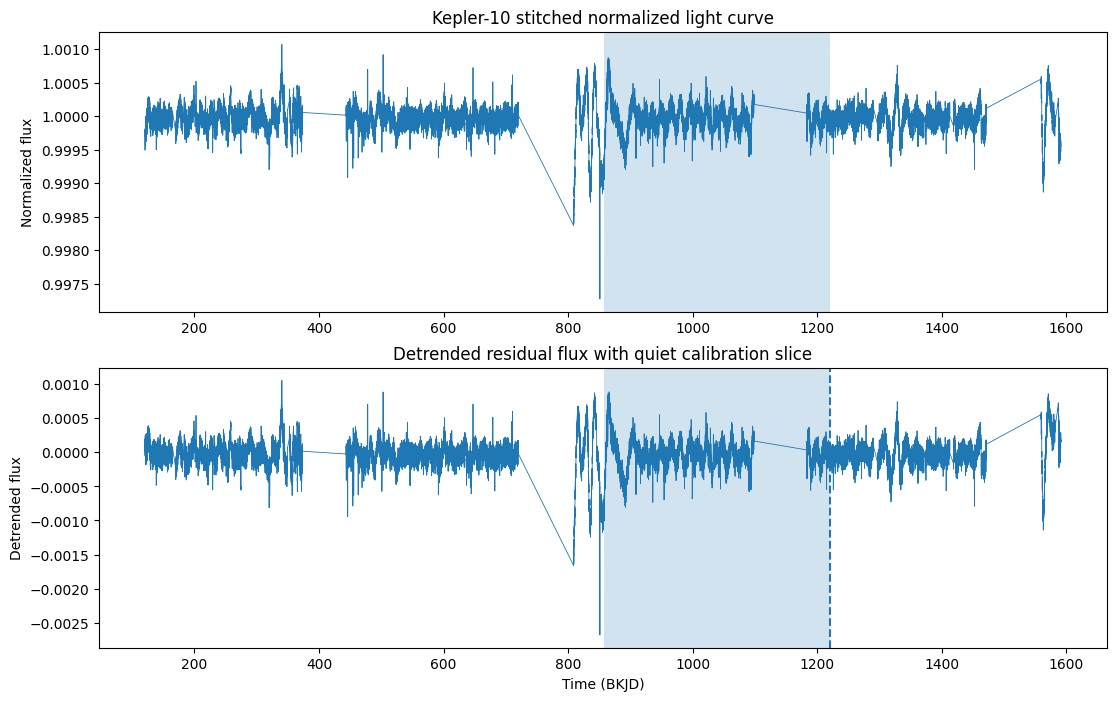

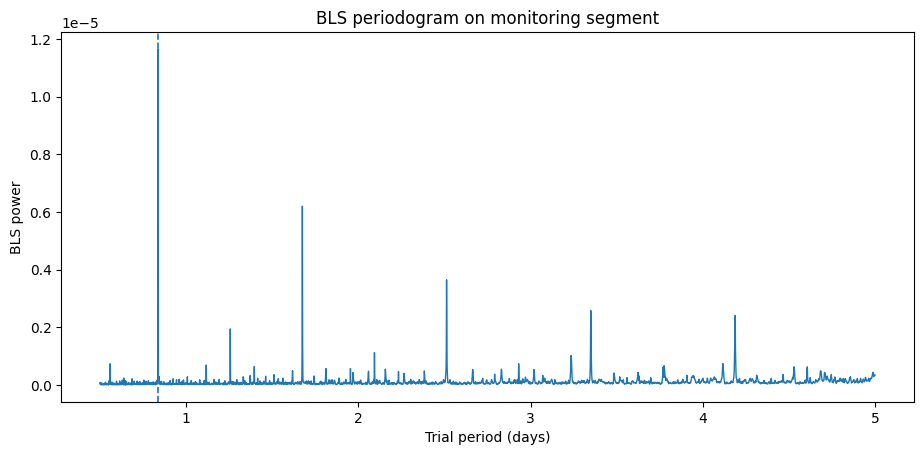

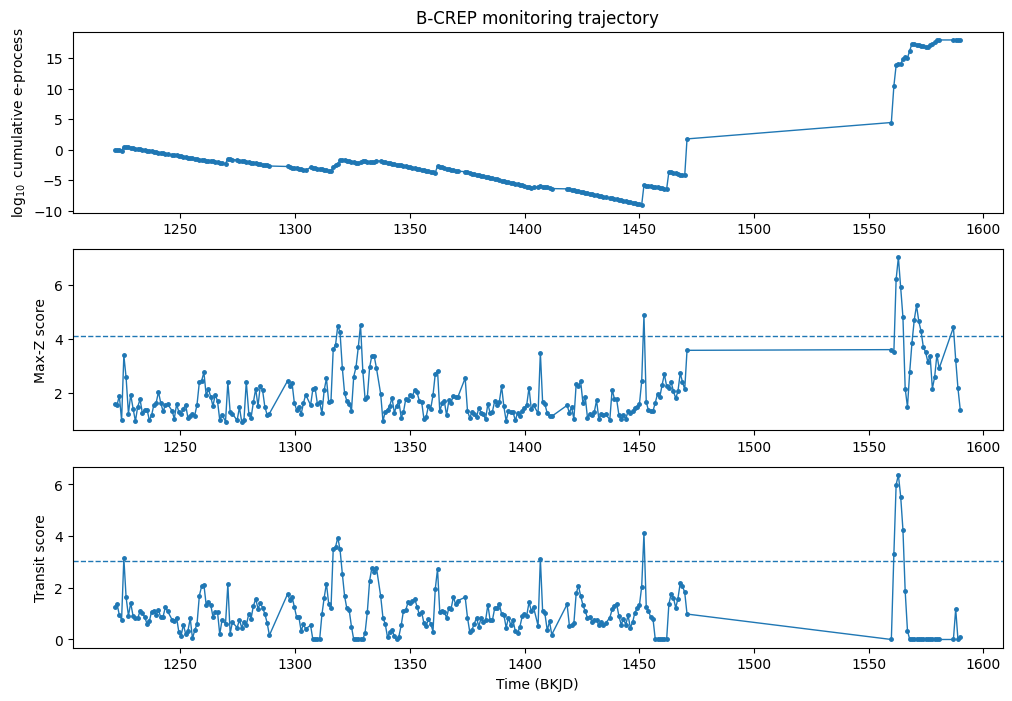

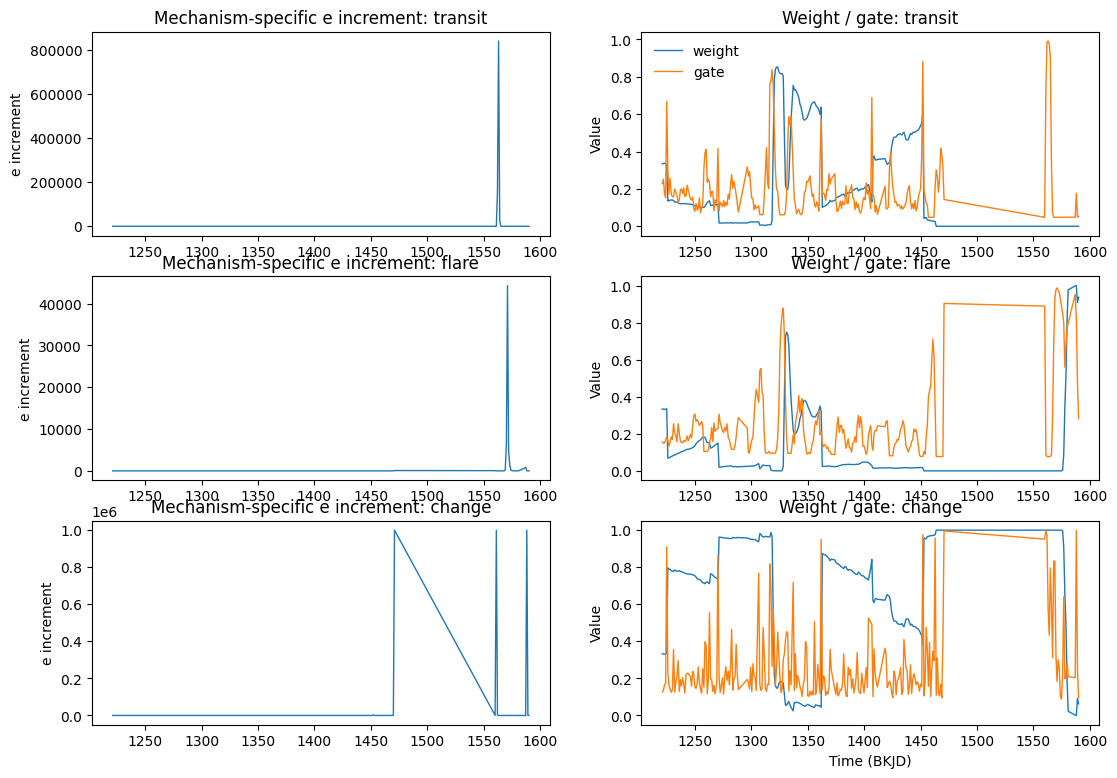

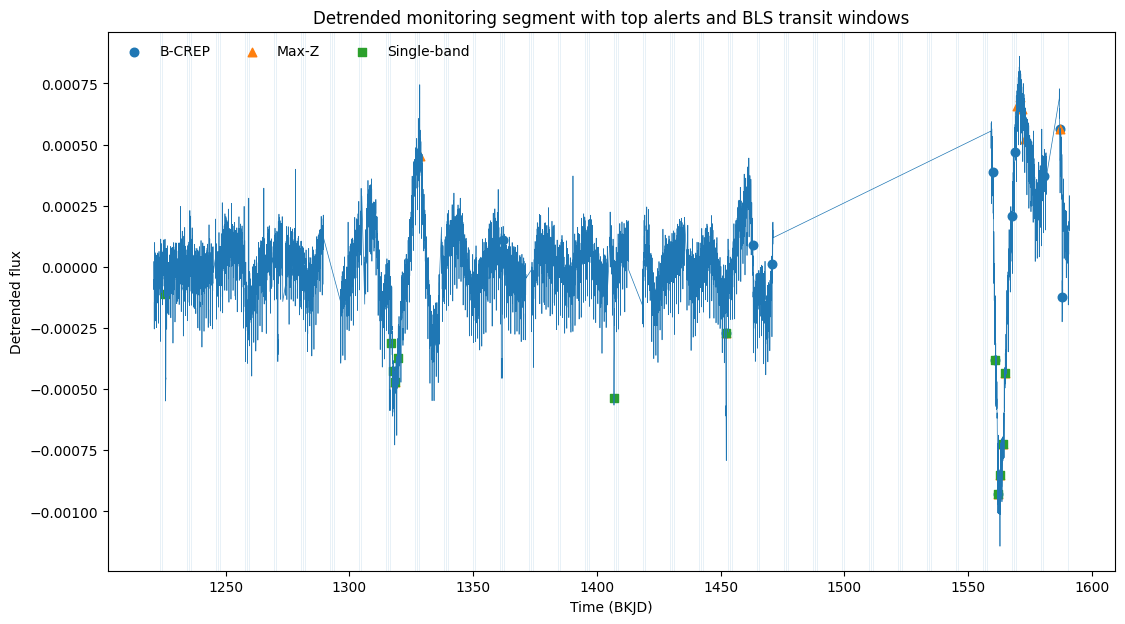

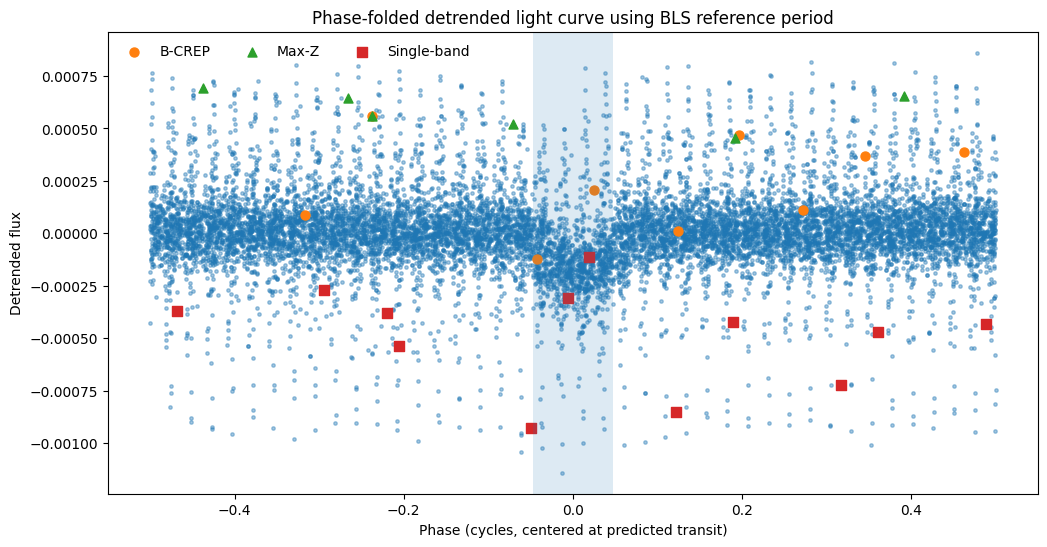

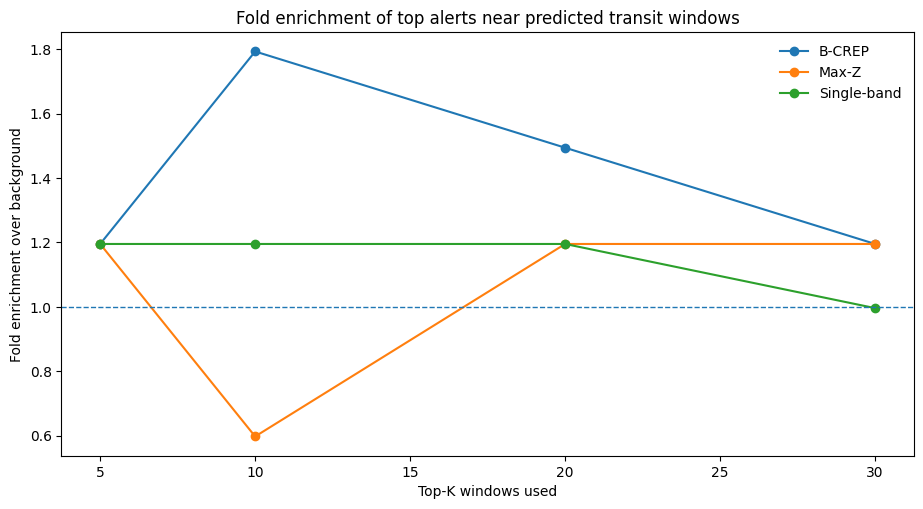

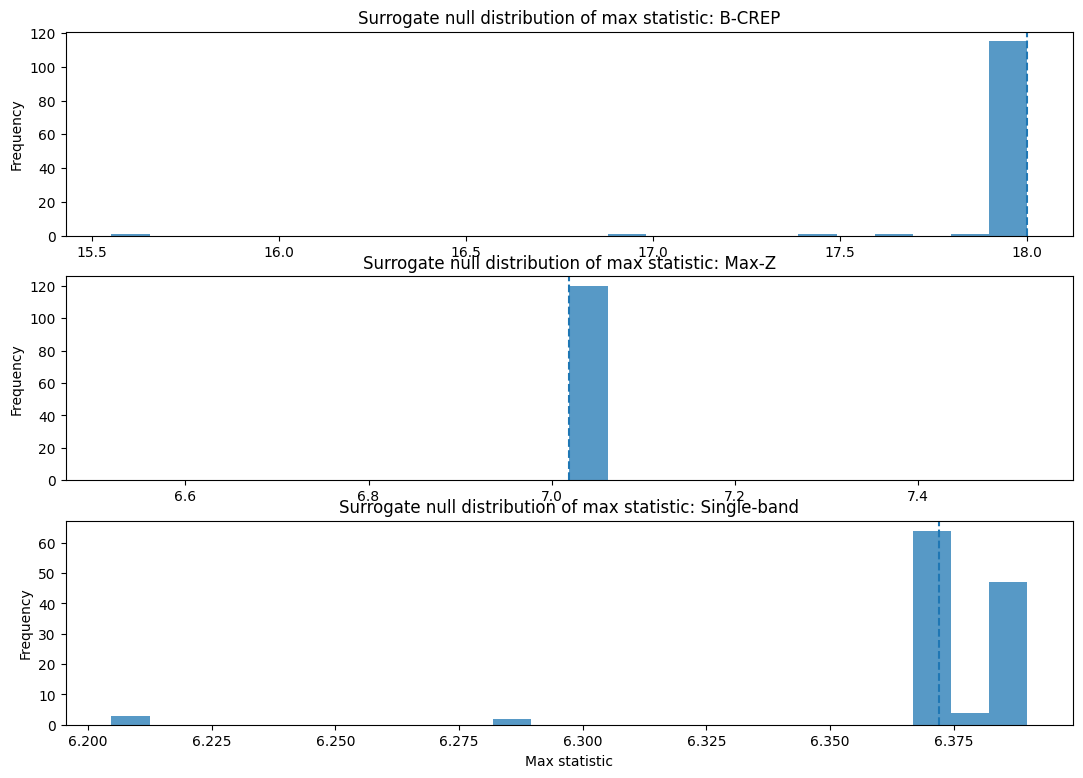

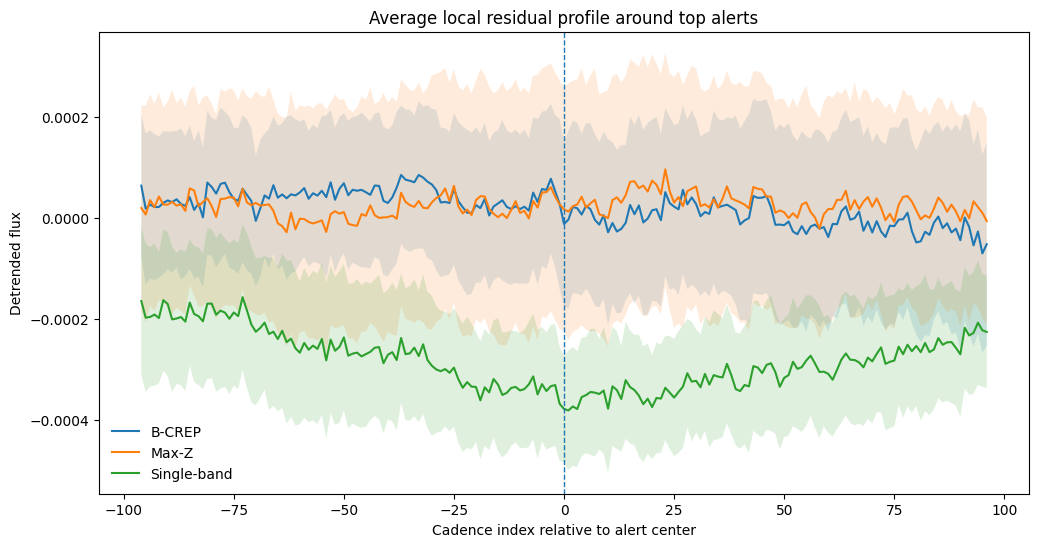

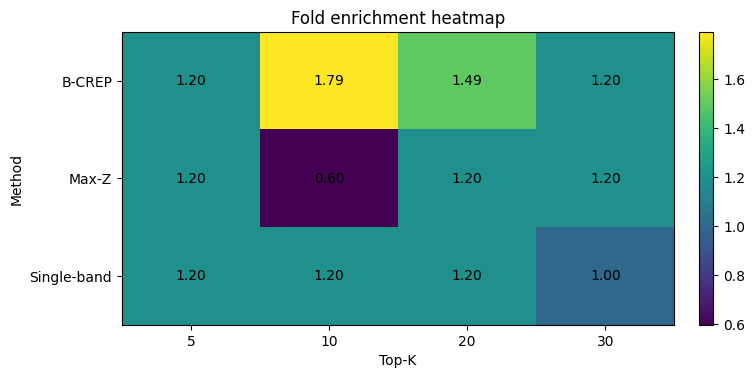


Results folder: /content/bcrep_realdata_results
ZIP archive   : /content/bcrep_realdata_results.zip
Done.


In [2]:
# ============================================================
# B-CREP real-data application for Kepler-10 (Colab-ready)
# ------------------------------------------------------------
# Purpose
#   Apply a practical Bayesian CREP-style monitor (B-CREP) to the
#   same real astronomical target used in the paper: Kepler-10.
#
# What this script does
#   1) downloads and stitches Kepler long-cadence light curves;
#   2) normalizes, detrends, and identifies a quiet calibration slice;
#   3) builds disjoint monitoring windows (safer than overlapping ones);
#   4) runs a practical B-CREP monitor with mechanism-adaptive Bayesian
#      predictive e-merging;
#   5) compares against weak benchmarks:
#         - Max-Z (naive max standardized residual),
#         - Single-band dip score (naive transit-threshold rule);
#   6) uses an automatically estimated Box Least Squares (BLS) period to
#      create objective real-data utility proxies:
#         - alert enrichment near predicted transit windows,
#         - phase concentration of top alerts,
#         - surrogate (circular-shift) significance of max statistics,
#         - average event profiles around top-ranked alerts;
#   7) saves all plots/tables, shows them inline, and creates a ZIP.
#
# Honest note
#   This is a practical application proxy of Methodology Part II, not a
#   full MCMC/horseshoe implementation. The Bayesian component enters via
#   posterior-predictive Student-t nulls, Beta-Bernoulli sparsity gating,
#   and mechanism-adaptive e-merging.
# ============================================================

import os
import sys
import json
import math
import shutil
import warnings
from dataclasses import dataclass

warnings.filterwarnings("ignore")

# -----------------------------
# Colab-friendly imports / installs
# -----------------------------
def maybe_install(package: str):
    try:
        __import__(package.split("==")[0].split(">=")[0])
    except Exception:
        import subprocess
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

maybe_install("lightkurve>=2.5")
maybe_install("astropy>=5.3")
maybe_install("statsmodels>=0.14")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from scipy import stats
from scipy.signal import medfilt
import lightkurve as lk
from astropy.timeseries import BoxLeastSquares

# -----------------------------
# Configuration
# -----------------------------
SEED = 20260324
rng = np.random.default_rng(SEED)

RESULTS_DIR = "/content/bcrep_realdata_results"
os.makedirs(RESULTS_DIR, exist_ok=True)
TABLE_DIR = os.path.join(RESULTS_DIR, "tables")
FIG_DIR = os.path.join(RESULTS_DIR, "figures")
os.makedirs(TABLE_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

CONFIG = {
    "target_name": "Kepler-10",
    "target_query": "KIC 11904151",
    "mission": "Kepler",
    "cadence": "long",
    "window_len": 48,
    "window_step": 48,
    "calibration_fraction": 0.25,
    "trend_kernel": 2001,
    "sigma_clip": 8.0,
    "bls_min_period": 0.5,
    "bls_max_period": 5.0,
    "bls_grid_size": 3000,
    "bls_duration_grid": [0.05, 0.08, 0.10, 0.12, 0.15, 0.20],
    "topk_alerts": 20,
    "topk_grid": [5, 10, 20, 30],
    "surrogate_reps": 120,
    "beta_a0": 1.0,
    "beta_b0": 9.0,
    "mech_names": ["transit", "flare", "change"],
}
with open(os.path.join(RESULTS_DIR, "config.json"), "w") as f:
    json.dump(CONFIG, f, indent=2)

# -----------------------------
# Utility helpers
# -----------------------------
def save_df(df: pd.DataFrame, name: str):
    csv_path = os.path.join(TABLE_DIR, f"{name}.csv")
    xlsx_path = os.path.join(TABLE_DIR, f"{name}.xlsx")
    df.to_csv(csv_path, index=False)
    try:
        df.to_excel(xlsx_path, index=False)
    except Exception:
        pass
    print(f"\n{name}:")
    display(df)
    return csv_path


def save_fig(fig, name: str, dpi: int = 180):
    path = os.path.join(FIG_DIR, f"{name}.png")
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    return path


def robust_mad(x):
    x = np.asarray(x, dtype=float)
    med = np.nanmedian(x)
    mad = np.nanmedian(np.abs(x - med))
    return 1.4826 * mad + 1e-12


def robust_z(x, center=None, scale=None):
    x = np.asarray(x, dtype=float)
    if center is None:
        center = np.nanmedian(x)
    if scale is None:
        scale = robust_mad(x)
    return (x - center) / (scale + 1e-12)


def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -30, 30)))


def softmax(logw):
    a = np.asarray(logw, dtype=float)
    a = a - np.max(a)
    w = np.exp(a)
    return w / np.sum(w)


def t_pdf(x, df, loc, scale):
    scale = max(float(scale), 1e-8)
    return stats.t.pdf(x, df=max(df, 2.1), loc=loc, scale=scale)


def ensure_odd(k):
    k = int(k)
    if k % 2 == 0:
        k += 1
    return max(k, 5)

# -----------------------------
# Bayesian predictive pieces
# -----------------------------
@dataclass
class NIGState:
    kappa: float
    mu: float
    alpha: float
    beta: float


def nig_from_data(x, mu0=None, kappa0=1.0, alpha0=2.0, beta0=None):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        if mu0 is None:
            mu0 = 0.0
        if beta0 is None:
            beta0 = 1.0
        return NIGState(float(kappa0), float(mu0), float(alpha0), float(beta0))

    if mu0 is None:
        mu0 = float(np.median(x))
    if beta0 is None:
        beta0 = float(np.var(x, ddof=1) + 1.0)
    n = len(x)
    xbar = float(np.mean(x))
    ss = float(np.sum((x - xbar) ** 2))
    kappa_n = kappa0 + n
    mu_n = (kappa0 * mu0 + n * xbar) / kappa_n
    alpha_n = alpha0 + 0.5 * n
    beta_n = beta0 + 0.5 * ss + (kappa0 * n * (xbar - mu0) ** 2) / (2.0 * kappa_n)
    return NIGState(float(kappa_n), float(mu_n), float(alpha_n), float(beta_n))


def nig_update(state: NIGState, x: float) -> NIGState:
    kappa_n = state.kappa + 1.0
    mu_n = (state.kappa * state.mu + x) / kappa_n
    alpha_n = state.alpha + 0.5
    beta_n = state.beta + 0.5 * (state.kappa * (x - state.mu) ** 2) / kappa_n
    return NIGState(float(kappa_n), float(mu_n), float(alpha_n), float(beta_n))


def nig_pred_params(state: NIGState):
    df = 2.0 * state.alpha
    scale = math.sqrt(state.beta * (state.kappa + 1.0) / (state.alpha * state.kappa))
    return df, state.mu, scale

# -----------------------------
# Data acquisition / preprocessing
# -----------------------------
def download_kepler10():
    print("Downloading Kepler-10 light curves via lightkurve ...")
    search = lk.search_lightcurve(CONFIG["target_query"], mission=CONFIG["mission"], cadence=CONFIG["cadence"])
    if len(search) == 0:
        raise RuntimeError("No light curves found for Kepler-10.")

    lcc = search.download_all(quality_bitmask="default")
    if lcc is None or len(lcc) == 0:
        raise RuntimeError("Download failed or returned no light curves.")

    cleaned = []
    for lc in lcc:
        try:
            x = lc.remove_nans()
            x = x.remove_outliers(sigma=CONFIG["sigma_clip"])
            x = x.normalize()
            cleaned.append(x)
        except Exception:
            continue

    if len(cleaned) == 0:
        raise RuntimeError("Could not clean any downloaded light curves.")

    stitched = lk.LightCurveCollection(cleaned).stitch()
    stitched = stitched.remove_nans()

    time = np.asarray(stitched.time.value, dtype=float)
    flux = np.asarray(stitched.flux.value, dtype=float)
    try:
        flux_err = np.asarray(stitched.flux_err.value, dtype=float)
    except Exception:
        flux_err = np.full_like(flux, np.nan)

    df = pd.DataFrame({"time": time, "flux": flux, "flux_err": flux_err})
    df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=["time", "flux"]).sort_values("time")
    df = df.drop_duplicates(subset=["time"]).reset_index(drop=True)
    return df


def detrend_flux(df: pd.DataFrame) -> pd.DataFrame:
    x = df.copy()
    flux = x["flux"].to_numpy(dtype=float)
    kernel = ensure_odd(min(CONFIG["trend_kernel"], len(flux) - (len(flux) + 1) % 2 - 1))
    if kernel < 5:
        kernel = 5
    trend = medfilt(flux, kernel_size=kernel)
    trend[trend == 0] = np.nanmedian(trend[trend != 0])
    detrended = flux / trend - 1.0
    x["trend"] = trend
    x["detrended"] = detrended
    return x


def choose_quiet_slice(detrended: np.ndarray, frac: float = 0.25):
    n = len(detrended)
    m = max(200, int(frac * n))
    step = max(20, m // 20)
    best_score = np.inf
    best = (0, m)
    for start in range(0, n - m + 1, step):
        seg = detrended[start:start + m]
        med = np.median(seg)
        sc = robust_mad(seg)
        z = (seg - med) / sc
        out_frac = np.mean(np.abs(z) > 3.0)
        rough = np.median(np.abs(np.diff(seg))) / (sc + 1e-12)
        skew_pen = abs(stats.skew(seg, bias=False, nan_policy="omit")) if len(seg) > 8 else 0.0
        score = out_frac + 0.35 * rough + 0.08 * skew_pen
        if score < best_score:
            best_score = score
            best = (start, start + m)
    return best[0], best[1], float(best_score)

# -----------------------------
# Window construction / features
# -----------------------------
def build_windows(df: pd.DataFrame, start_idx: int, end_idx: int, wlen: int, step: int):
    rows = []
    for s in range(start_idx, end_idx - wlen + 1, step):
        e = s + wlen
        sub = df.iloc[s:e]
        rows.append({
            "start_idx": s,
            "end_idx": e,
            "t_start": float(sub["time"].iloc[0]),
            "t_end": float(sub["time"].iloc[-1]),
            "t_center": float(np.median(sub["time"])),
            "n_points": int(len(sub)),
        })
    return pd.DataFrame(rows)


def extract_scores(zwin: np.ndarray):
    zwin = np.asarray(zwin, dtype=float)
    n = len(zwin)
    k = max(3, n // 8)
    z_sorted = np.sort(zwin)
    transit = max(0.0, -float(np.mean(z_sorted[:k])))
    flare = max(0.0,  float(np.mean(z_sorted[-k:])))
    first = np.mean(zwin[: n // 2])
    second = np.mean(zwin[n // 2 :])
    change = abs(second - first)
    maxz = np.max(np.abs(zwin))
    return {
        "transit": transit,
        "flare": flare,
        "change": change,
        "maxz": float(maxz),
        "dip_depth": float(np.min(zwin)),
        "peak_height": float(np.max(zwin)),
        "win_mean": float(np.mean(zwin)),
    }


def score_windows(df: pd.DataFrame, windows: pd.DataFrame, cal_center: float, cal_scale: float):
    out = []
    for _, row in windows.iterrows():
        sub = df.iloc[int(row.start_idx): int(row.end_idx)]
        zwin = robust_z(sub["detrended"].to_numpy(dtype=float), center=cal_center, scale=cal_scale)
        feats = extract_scores(zwin)
        out.append({**row.to_dict(), **feats})
    return pd.DataFrame(out)

# -----------------------------
# BLS reference model
# -----------------------------
def run_bls(time, flux):
    time = np.asarray(time, dtype=float)
    flux = np.asarray(flux, dtype=float)
    bls = BoxLeastSquares(time, flux)
    periods = np.linspace(CONFIG["bls_min_period"], CONFIG["bls_max_period"], CONFIG["bls_grid_size"])
    durations = np.asarray(CONFIG["bls_duration_grid"], dtype=float)
    power = bls.power(periods, durations)
    ix = int(np.argmax(power.power))
    best = {
        "period": float(power.period[ix]),
        "duration": float(power.duration[ix]),
        "transit_time": float(power.transit_time[ix]),
        "depth": float(power.depth[ix]),
        "snr": float(power.power[ix]),
        "period_grid": np.asarray(power.period, dtype=float),
        "power_grid": np.asarray(power.power, dtype=float),
    }
    return best


def phase_distance(t, period, transit_time):
    phase = ((t - transit_time + 0.5 * period) % period) - 0.5 * period
    return phase / period


def near_predicted_transit(t, period, transit_time, duration, buffer_factor=0.75):
    dist_days = abs(((t - transit_time + 0.5 * period) % period) - 0.5 * period)
    tol = 0.5 * duration * (1.0 + buffer_factor)
    return dist_days <= tol

# -----------------------------
# Method runners
# -----------------------------
def run_bcrep(cal_df: pd.DataFrame, mon_df: pd.DataFrame):
    mech_names = CONFIG["mech_names"]
    states = {}
    q90 = {}
    q95 = {}
    shift = {}

    for mech in mech_names:
        x = cal_df[mech].to_numpy(dtype=float)
        mu0 = float(np.median(x))
        beta0 = float(np.var(x, ddof=1) + 1.0)
        states[mech] = nig_from_data(x, mu0=mu0, beta0=beta0)
        q90[mech] = float(np.quantile(x, 0.90))
        q95[mech] = float(np.quantile(x, 0.95))
        shift[mech] = max(q95[mech] - mu0, 1.5 * robust_mad(x))

    counts = {m: 0.0 for m in mech_names}
    log_mech = np.zeros(len(mech_names))
    cumulative = 1.0
    rows = []

    a0 = CONFIG["beta_a0"]
    b0 = CONFIG["beta_b0"]

    for t, row in mon_df.reset_index(drop=True).iterrows():
        E_mech = {}
        gates = {}
        weights = softmax(log_mech)
        inc_components = []

        for j, mech in enumerate(mech_names):
            s = float(row[mech])
            df0, loc0, sc0 = nig_pred_params(states[mech])
            g0 = t_pdf(s, df0, loc0, sc0)
            pi = (a0 + counts[mech]) / (a0 + b0 + max(t, 1))
            g_shift = t_pdf(s, df0, loc0 + shift[mech], 1.25 * sc0)
            g1 = (1.0 - pi) * g0 + pi * g_shift
            e = float(np.clip(g1 / max(g0, 1e-12), 1e-6, 1e6))
            gate = float(sigmoid((s - q90[mech]) / (sc0 + 1e-8)))

            E_mech[mech] = e
            gates[mech] = gate
            inc_components.append(weights[j] * e)

            # update sparsity counts and null state conservatively
            counts[mech] += gate
            if gate < 0.45:
                states[mech] = nig_update(states[mech], s)

        merged_increment = float(np.clip(np.sum(inc_components), 1e-6, 1e6))
        cumulative = float(np.clip(cumulative * merged_increment, 1e-12, 1e18))
        log_mech += np.log(np.array([E_mech[m] for m in mech_names]) + 1e-12)

        rows.append({
            "window_index": int(t),
            "t_center": float(row["t_center"]),
            "bcrep_increment": merged_increment,
            "bcrep_cumE": cumulative,
            "bcrep_log10_cumE": float(np.log10(max(cumulative, 1e-12))),
            **{f"E_{m}": E_mech[m] for m in mech_names},
            **{f"gate_{m}": gates[m] for m in mech_names},
            **{f"w_{m}": float(weights[k]) for k, m in enumerate(mech_names)},
        })

    return pd.DataFrame(rows)


def run_benchmarks(mon_df: pd.DataFrame, cal_df: pd.DataFrame):
    maxz_thr95 = float(np.quantile(cal_df["maxz"], 0.95))
    transit_thr95 = float(np.quantile(cal_df["transit"], 0.95))

    out = mon_df[["t_center", "maxz", "transit"]].copy()
    out["maxz_excess"] = out["maxz"] / max(maxz_thr95, 1e-8)
    out["singleband_excess"] = out["transit"] / max(transit_thr95, 1e-8)
    return out, {"maxz_thr95": maxz_thr95, "transit_thr95": transit_thr95}

# -----------------------------
# Surrogate diagnostics
# -----------------------------
def circular_shift(arr, shift):
    shift = int(shift) % len(arr)
    return np.concatenate([arr[-shift:], arr[:-shift]]) if shift > 0 else arr.copy()


def build_surrogate_df(df, monitor_start_idx, shifted_detrended):
    x = df.copy()
    x.loc[monitor_start_idx:, "detrended"] = shifted_detrended
    return x


def run_methods_from_df(df_proc, cal_start, cal_end, mon_start, mon_end):
    cal_center = float(np.median(df_proc.loc[cal_start:cal_end - 1, "detrended"]))
    cal_scale = float(robust_mad(df_proc.loc[cal_start:cal_end - 1, "detrended"]))

    cal_win = build_windows(df_proc, cal_start, cal_end, CONFIG["window_len"], CONFIG["window_step"])
    mon_win = build_windows(df_proc, mon_start, mon_end, CONFIG["window_len"], CONFIG["window_step"])
    cal_sc = score_windows(df_proc, cal_win, cal_center, cal_scale)
    mon_sc = score_windows(df_proc, mon_win, cal_center, cal_scale)
    bc = run_bcrep(cal_sc, mon_sc)
    bm, thr = run_benchmarks(mon_sc, cal_sc)
    merged = mon_sc.merge(bc, on="t_center").merge(bm, on=["t_center", "maxz", "transit"])
    return merged, cal_sc, thr

# -----------------------------
# Main workflow
# -----------------------------
raw_df = download_kepler10()
proc_df = detrend_flux(raw_df)

cal_start, cal_end, quiet_score = choose_quiet_slice(proc_df["detrended"].to_numpy(dtype=float), frac=CONFIG["calibration_fraction"])
monitor_start = cal_end
monitor_end = len(proc_df)

prep_summary = pd.DataFrame({
    "quantity": [
        "target", "n_total_points", "time_min", "time_max", "calibration_start_idx",
        "calibration_end_idx", "monitor_start_idx", "window_len", "window_step", "quietness_score"
    ],
    "value": [
        CONFIG["target_name"], len(proc_df), proc_df["time"].min(), proc_df["time"].max(),
        cal_start, cal_end, monitor_start, CONFIG["window_len"], CONFIG["window_step"], quiet_score
    ]
})
save_df(prep_summary, "preprocessing_summary")

# Calibration / monitoring scores
full_results, cal_scores, benchmark_thresholds = run_methods_from_df(proc_df, cal_start, cal_end, monitor_start, monitor_end)

# BLS reference model on monitoring segment
bls_ref = run_bls(
    proc_df.loc[monitor_start:, "time"].to_numpy(dtype=float),
    proc_df.loc[monitor_start:, "detrended"].to_numpy(dtype=float),
)
bls_table = pd.DataFrame([{
    "best_period_days": bls_ref["period"],
    "best_duration_days": bls_ref["duration"],
    "best_transit_time": bls_ref["transit_time"],
    "depth": bls_ref["depth"],
    "bls_power": bls_ref["snr"],
}])
save_df(bls_table, "bls_reference_summary")

# Attach phase / transit diagnostics
full_results["phase_dist"] = full_results["t_center"].apply(
    lambda t: phase_distance(t, bls_ref["period"], bls_ref["transit_time"])
)
full_results["near_predicted_transit"] = full_results["t_center"].apply(
    lambda t: near_predicted_transit(t, bls_ref["period"], bls_ref["transit_time"], bls_ref["duration"])
)
full_results["phase_abs"] = np.abs(full_results["phase_dist"])

# Alert rankings by method
TOPK = CONFIG["topk_alerts"]
method_rank_specs = {
    "B-CREP": "bcrep_increment",
    "Max-Z": "maxz",
    "Single-band": "transit",
}

alert_tables = []
for method, score_col in method_rank_specs.items():
    tmp = full_results.sort_values(score_col, ascending=False).head(TOPK).copy()
    tmp.insert(0, "method", method)
    tmp.insert(1, "rank", np.arange(1, len(tmp) + 1))
    tmp["score_used"] = score_col
    tmp["score_value"] = tmp[score_col]
    alert_tables.append(tmp[[
        "method", "rank", "t_center", "score_used", "score_value", "near_predicted_transit",
        "phase_abs", "bcrep_increment", "bcrep_log10_cumE", "maxz", "transit", "flare", "change"
    ]])

alerts_df = pd.concat(alert_tables, ignore_index=True)
save_df(alerts_df, "top_alerts_by_method")

# Enrichment table across top-k values
background_rate = float(full_results["near_predicted_transit"].mean())
enrich_rows = []
for method, score_col in method_rank_specs.items():
    tmp = full_results.sort_values(score_col, ascending=False).copy()
    for k in CONFIG["topk_grid"]:
        topk = tmp.head(k)
        hit_rate = float(topk["near_predicted_transit"].mean())
        enrich = hit_rate / max(background_rate, 1e-8)
        mean_phase_abs = float(topk["phase_abs"].mean())
        enrich_rows.append({
            "method": method,
            "topk": k,
            "hit_rate": hit_rate,
            "background_rate": background_rate,
            "fold_enrichment": enrich,
            "mean_abs_phase_distance": mean_phase_abs,
        })
enrich_df = pd.DataFrame(enrich_rows)
save_df(enrich_df, "alert_enrichment_table")

# Phase concentration table on top-K alerts
phase_rows = []
for method, score_col in method_rank_specs.items():
    tmp = full_results.sort_values(score_col, ascending=False).head(TOPK)
    theta = 2.0 * np.pi * tmp["phase_dist"].to_numpy(dtype=float)
    R = float(np.sqrt(np.mean(np.cos(theta)) ** 2 + np.mean(np.sin(theta)) ** 2))
    phase_rows.append({
        "method": method,
        "topk": TOPK,
        "phase_resultant_length_R": R,
        "mean_abs_phase_distance": float(tmp["phase_abs"].mean()),
        "fraction_near_predicted_transit": float(tmp["near_predicted_transit"].mean()),
    })
phase_df = pd.DataFrame(phase_rows)
save_df(phase_df, "phase_concentration_table")

# Surrogate significance by circular shifts on monitoring segment
monitor_detrended = proc_df.loc[monitor_start:, "detrended"].to_numpy(dtype=float)
valid_shifts = np.arange(CONFIG["window_len"], max(len(monitor_detrended) - CONFIG["window_len"], CONFIG["window_len"] + 1))
if len(valid_shifts) < CONFIG["surrogate_reps"]:
    surrogate_shifts = rng.choice(valid_shifts, size=CONFIG["surrogate_reps"], replace=True)
else:
    surrogate_shifts = rng.choice(valid_shifts, size=CONFIG["surrogate_reps"], replace=False)

real_max = {
    "B-CREP": float(full_results["bcrep_log10_cumE"].max()),
    "Max-Z": float(full_results["maxz"].max()),
    "Single-band": float(full_results["transit"].max()),
}
surr_rows = []
all_surr = {"B-CREP": [], "Max-Z": [], "Single-band": []}

print("\nRunning surrogate diagnostics (circular shifts) ...")
for rep, sh in enumerate(surrogate_shifts, start=1):
    shifted = circular_shift(monitor_detrended, int(sh))
    surr_df = build_surrogate_df(proc_df, monitor_start, shifted)
    surr_res, _, _ = run_methods_from_df(surr_df, cal_start, cal_end, monitor_start, monitor_end)
    all_surr["B-CREP"].append(float(surr_res["bcrep_log10_cumE"].max()))
    all_surr["Max-Z"].append(float(surr_res["maxz"].max()))
    all_surr["Single-band"].append(float(surr_res["transit"].max()))
    if rep % 20 == 0:
        print(f"  completed {rep}/{len(surrogate_shifts)} surrogates")

for method in ["B-CREP", "Max-Z", "Single-band"]:
    x = np.asarray(all_surr[method], dtype=float)
    surr_rows.append({
        "method": method,
        "real_max_stat": real_max[method],
        "surrogate_mean": float(np.mean(x)),
        "surrogate_sd": float(np.std(x, ddof=1)),
        "surrogate_q95": float(np.quantile(x, 0.95)),
        "surrogate_q99": float(np.quantile(x, 0.99)),
        "empirical_p_value": float((1.0 + np.sum(x >= real_max[method])) / (1.0 + len(x))),
    })
surr_df = pd.DataFrame(surr_rows)
save_df(surr_df, "surrogate_significance_table")

# Average local profiles around top alerts
PROFILE_RADIUS = 2 * CONFIG["window_len"]
profile_rows = []
profile_store = {}
for method, score_col in method_rank_specs.items():
    top_idx = full_results.sort_values(score_col, ascending=False).head(TOPK)["window_index"].to_numpy(dtype=int)
    segments = []
    for win_idx in top_idx:
        row = full_results.iloc[win_idx]
        center_global_idx = int((row["start_idx"] + row["end_idx"]) // 2)
        lo = max(0, center_global_idx - PROFILE_RADIUS)
        hi = min(len(proc_df), center_global_idx + PROFILE_RADIUS + 1)
        seg = proc_df.iloc[lo:hi]["detrended"].to_numpy(dtype=float)
        if len(seg) < 2 * PROFILE_RADIUS + 1:
            pad_left = center_global_idx - lo
            pad_right = hi - center_global_idx - 1
            tmp = np.full(2 * PROFILE_RADIUS + 1, np.nan)
            start = PROFILE_RADIUS - pad_left
            end = PROFILE_RADIUS + pad_right + 1
            tmp[start:end] = seg
            seg = tmp
        segments.append(seg)
    arr = np.vstack(segments)
    m = np.nanmean(arr, axis=0)
    se = np.nanstd(arr, axis=0, ddof=1) / np.sqrt(np.sum(np.isfinite(arr), axis=0))
    rel_idx = np.arange(-PROFILE_RADIUS, PROFILE_RADIUS + 1)
    profile_store[method] = (rel_idx, m, se)
    profile_rows.append({
        "method": method,
        "topk": TOPK,
        "min_mean_profile": float(np.nanmin(m)),
        "max_mean_profile": float(np.nanmax(m)),
        "mean_center_value": float(m[PROFILE_RADIUS]),
    })
profile_table = pd.DataFrame(profile_rows)
save_df(profile_table, "average_profile_summary")

# Merge core results table for later manuscript work
save_df(full_results, "window_level_results")

# -----------------------------
# Plots
# -----------------------------
# 1. Raw + detrended light curve
fig = plt.figure(figsize=(13, 8))
ax1 = plt.subplot(2, 1, 1)
ax1.plot(proc_df["time"], proc_df["flux"], lw=0.6)
ax1.axvspan(proc_df["time"].iloc[cal_start], proc_df["time"].iloc[cal_end - 1], alpha=0.20)
ax1.set_title("Kepler-10 stitched normalized light curve")
ax1.set_ylabel("Normalized flux")

ax2 = plt.subplot(2, 1, 2, sharex=ax1)
ax2.plot(proc_df["time"], proc_df["detrended"], lw=0.6)
ax2.axvspan(proc_df["time"].iloc[cal_start], proc_df["time"].iloc[cal_end - 1], alpha=0.20)
ax2.axvline(proc_df["time"].iloc[monitor_start], ls="--")
ax2.set_title("Detrended residual flux with quiet calibration slice")
ax2.set_xlabel("Time (BKJD)")
ax2.set_ylabel("Detrended flux")
save_fig(fig, "lightcurve_and_detrended")

# 2. BLS periodogram
fig = plt.figure(figsize=(11, 4.8))
ax = plt.gca()
ax.plot(bls_ref["period_grid"], bls_ref["power_grid"], lw=1.0)
ax.axvline(bls_ref["period"], ls="--", lw=1.2)
ax.set_title("BLS periodogram on monitoring segment")
ax.set_xlabel("Trial period (days)")
ax.set_ylabel("BLS power")
save_fig(fig, "bls_periodogram")

# 3. Monitoring trajectories
fig = plt.figure(figsize=(12, 8))
ax1 = plt.subplot(3, 1, 1)
ax1.plot(full_results["t_center"], full_results["bcrep_log10_cumE"], marker="o", ms=2.5, lw=1)
ax1.set_ylabel(r"$\log_{10}$ cumulative e-process")
ax1.set_title("B-CREP monitoring trajectory")

ax2 = plt.subplot(3, 1, 2, sharex=ax1)
ax2.plot(full_results["t_center"], full_results["maxz"], marker="o", ms=2.5, lw=1, label="Max-Z")
ax2.axhline(benchmark_thresholds["maxz_thr95"], ls="--", lw=1)
ax2.set_ylabel("Max-Z score")

ax3 = plt.subplot(3, 1, 3, sharex=ax1)
ax3.plot(full_results["t_center"], full_results["transit"], marker="o", ms=2.5, lw=1, label="Single-band dip")
ax3.axhline(benchmark_thresholds["transit_thr95"], ls="--", lw=1)
ax3.set_ylabel("Transit score")
ax3.set_xlabel("Time (BKJD)")
save_fig(fig, "monitoring_trajectories")

# 4. B-CREP mechanism internals
fig = plt.figure(figsize=(13, 9))
mechs = CONFIG["mech_names"]
for j, mech in enumerate(mechs, start=1):
    ax = plt.subplot(3, 2, 2 * j - 1)
    ax.plot(full_results["t_center"], full_results[f"E_{mech}"], lw=1.0)
    ax.set_title(f"Mechanism-specific e increment: {mech}")
    ax.set_ylabel("e increment")
    ax = plt.subplot(3, 2, 2 * j)
    ax.plot(full_results["t_center"], full_results[f"w_{mech}"], lw=1.0, label="weight")
    ax.plot(full_results["t_center"], full_results[f"gate_{mech}"], lw=1.0, label="gate")
    ax.set_title(f"Weight / gate: {mech}")
    ax.set_ylabel("Value")
    if j == 1:
        ax.legend(frameon=False)
plt.xlabel("Time (BKJD)")
save_fig(fig, "bcrep_mechanisms_weights_gates")

# 5. Detrended monitoring curve with top alerts
fig = plt.figure(figsize=(13, 7))
ax = plt.gca()
mask_mon = proc_df.index >= monitor_start
ax.plot(proc_df.loc[mask_mon, "time"], proc_df.loc[mask_mon, "detrended"], lw=0.5)

marker_map = {"B-CREP": "o", "Max-Z": "^", "Single-band": "s"}
for method, score_col in method_rank_specs.items():
    top = full_results.sort_values(score_col, ascending=False).head(12)
    y = np.interp(top["t_center"], proc_df["time"], proc_df["detrended"])
    ax.scatter(top["t_center"], y, s=38, marker=marker_map[method], label=method)

# overlay predicted transit centers in monitoring span
mon_times = proc_df.loc[mask_mon, "time"].to_numpy(dtype=float)
period = bls_ref["period"]
t0 = bls_ref["transit_time"]
dur = bls_ref["duration"]
centers = []
cur = t0
while cur < mon_times.min():
    cur += period
while cur <= mon_times.max():
    centers.append(cur)
    cur += period
for c in centers:
    ax.axvspan(c - 0.5 * dur, c + 0.5 * dur, alpha=0.10)

ax.set_title("Detrended monitoring segment with top alerts and BLS transit windows")
ax.set_xlabel("Time (BKJD)")
ax.set_ylabel("Detrended flux")
ax.legend(frameon=False, ncol=3)
save_fig(fig, "detrended_monitoring_with_alerts")

# 6. Phase-folded view with top alerts
fig = plt.figure(figsize=(12, 6))
ax = plt.gca()
phase = phase_distance(proc_df.loc[mask_mon, "time"], period, t0)
ax.scatter(phase, proc_df.loc[mask_mon, "detrended"], s=6, alpha=0.4)
for method, score_col in method_rank_specs.items():
    top = full_results.sort_values(score_col, ascending=False).head(12)
    top_phase = phase_distance(top["t_center"], period, t0)
    top_y = np.interp(top["t_center"], proc_df["time"], proc_df["detrended"])
    ax.scatter(top_phase, top_y, s=42, marker=marker_map[method], label=method)
ax.axvspan(-0.5 * dur / period, 0.5 * dur / period, alpha=0.15)
ax.set_title("Phase-folded detrended light curve using BLS reference period")
ax.set_xlabel("Phase (cycles, centered at predicted transit)")
ax.set_ylabel("Detrended flux")
ax.legend(frameon=False, ncol=3)
save_fig(fig, "phase_folded_alerts")

# 7. Alert enrichment curves
fig = plt.figure(figsize=(11, 5.5))
ax = plt.gca()
for method in method_rank_specs.keys():
    sub = enrich_df[enrich_df["method"] == method]
    ax.plot(sub["topk"], sub["fold_enrichment"], marker="o", lw=1.5, label=method)
ax.axhline(1.0, ls="--", lw=1.0)
ax.set_title("Fold enrichment of top alerts near predicted transit windows")
ax.set_xlabel("Top-K windows used")
ax.set_ylabel("Fold enrichment over background")
ax.legend(frameon=False)
save_fig(fig, "alert_enrichment_curves")

# 8. Surrogate histograms
fig = plt.figure(figsize=(13, 9))
for j, method in enumerate(["B-CREP", "Max-Z", "Single-band"], start=1):
    ax = plt.subplot(3, 1, j)
    x = np.asarray(all_surr[method], dtype=float)
    ax.hist(x, bins=24, alpha=0.75)
    ax.axvline(real_max[method], ls="--", lw=1.5)
    ax.set_title(f"Surrogate null distribution of max statistic: {method}")
    ax.set_ylabel("Frequency")
    if j == 3:
        ax.set_xlabel("Max statistic")
save_fig(fig, "surrogate_histograms")

# 9. Average local profiles around top alerts
fig = plt.figure(figsize=(12, 6))
ax = plt.gca()
for method, (rel_idx, m, se) in profile_store.items():
    ax.plot(rel_idx, m, lw=1.5, label=method)
    ax.fill_between(rel_idx, m - 1.96 * se, m + 1.96 * se, alpha=0.15)
ax.axvline(0, ls="--", lw=1.0)
ax.set_title("Average local residual profile around top alerts")
ax.set_xlabel("Cadence index relative to alert center")
ax.set_ylabel("Detrended flux")
ax.legend(frameon=False)
save_fig(fig, "average_profiles_top_alerts")

# 10. Metric comparison heatmap-like table plot
metric_pivot = enrich_df.pivot(index="method", columns="topk", values="fold_enrichment")
fig = plt.figure(figsize=(7.8, 3.8))
ax = plt.gca()
im = ax.imshow(metric_pivot.to_numpy(dtype=float), aspect="auto")
ax.set_xticks(np.arange(metric_pivot.shape[1]))
ax.set_xticklabels(metric_pivot.columns)
ax.set_yticks(np.arange(metric_pivot.shape[0]))
ax.set_yticklabels(metric_pivot.index)
for i in range(metric_pivot.shape[0]):
    for j in range(metric_pivot.shape[1]):
        ax.text(j, i, f"{metric_pivot.iloc[i, j]:.2f}", ha="center", va="center")
ax.set_title("Fold enrichment heatmap")
ax.set_xlabel("Top-K")
ax.set_ylabel("Method")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
save_fig(fig, "fold_enrichment_heatmap")

# -----------------------------
# Final ZIP bundle
# -----------------------------
zip_path = shutil.make_archive(RESULTS_DIR, "zip", RESULTS_DIR)
print("\nResults folder:", RESULTS_DIR)
print("ZIP archive   :", zip_path)
print("Done.")


Nile Bayesian

Nile setup: calibration on 1871–1900, monitoring on 1901–1970, and disjoint 5-year blocks, while adapting Methodology Part II into a univariate Nile-specific B-CREP monitor rather than a generic astronomy template.

What it includes:

B-CREP for Nile with three adaptive mechanisms: drop, rise, and change
weak benchmark comparators: Max-Z and Single-band drop
many plots and tables, all shown inline and auto-saved
ZIP archive creation at the end
outputs designed for manuscript writing:
preprocessing summary
reference change summary
detection summary
top alerts table
enrichment near the intervention era
temporal concentration table
permutation-surrogate significance table
average profile summary
full window-level results

Loading and preprocessing Nile data ...
Loading Nile dataset from statsmodels ...

preprocessing_summary:


,dataset,units,n_points,year_min,year_max,calibration_start_year,calibration_end_year,monitoring_start_year,monitoring_end_year,block_size_years,robust_center_median,robust_scale_mad
0,Nile River annual flow,10^8 m^3,100,1871,1970,1871,1900,1901,1970,5,1115.0,148.26



reference_change_summary:


,reference_change_year,reference_halfwidth_years,offline_estimated_change_year,left_segment_end_year,right_segment_start_year,offline_rss
0,1898,10,1899,1898,1899,1.597457e+06



Running B-CREP monitoring on disjoint 5-year Nile blocks ...

window_level_results:


...


average_profile_summary:


,method,topk,min_mean_profile,max_mean_profile,mean_center_value
0,B-CREP,7,-2.124646,-0.990538,-2.124646
1,Max-Z,7,-2.426240,-0.941396,-1.912663
2,Single-band,7,-2.568846,-0.856603,-2.093812



detection_summary:


,method,threshold,first_cross_index,first_cross_center_year,value_at_cross
0,B-CREP,10.00,None,None,None
1,B-CREP,65.45,None,None,None
2,Max-Z,10.00,None,None,None
3,Max-Z,65.45,None,None,None
4,Single-band,10.00,None,None,None
5,Single-band,65.45,None,None,None



Generating plots ...


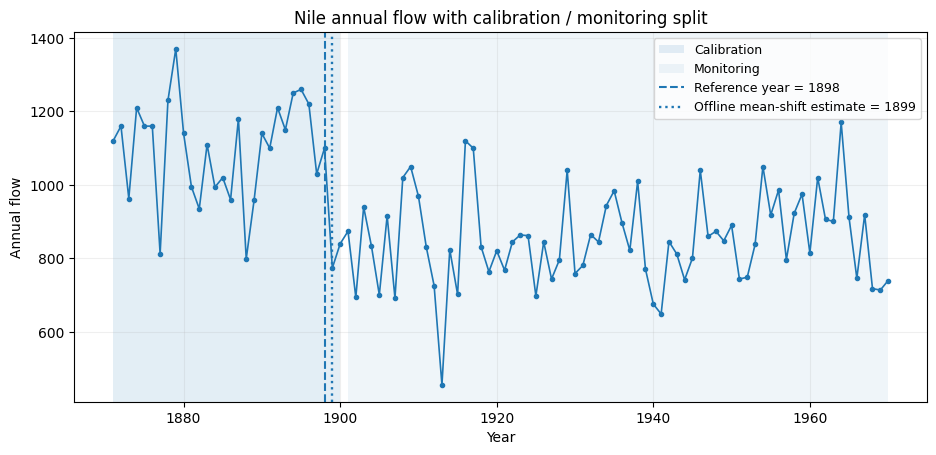

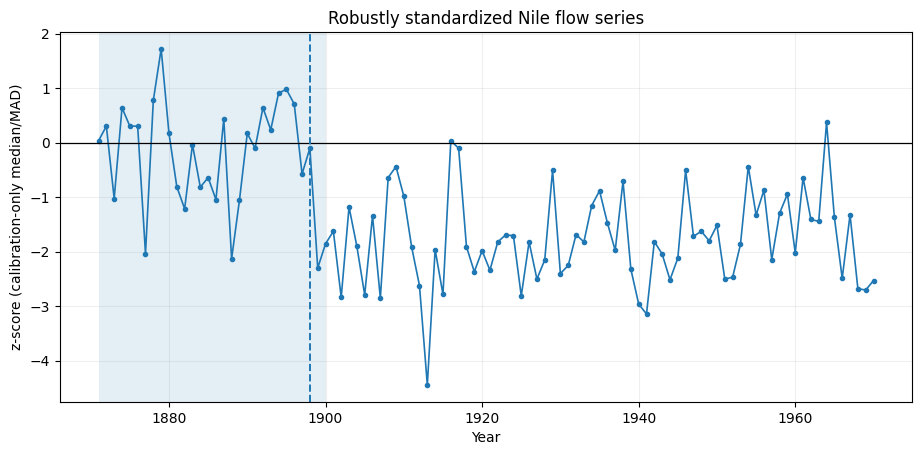

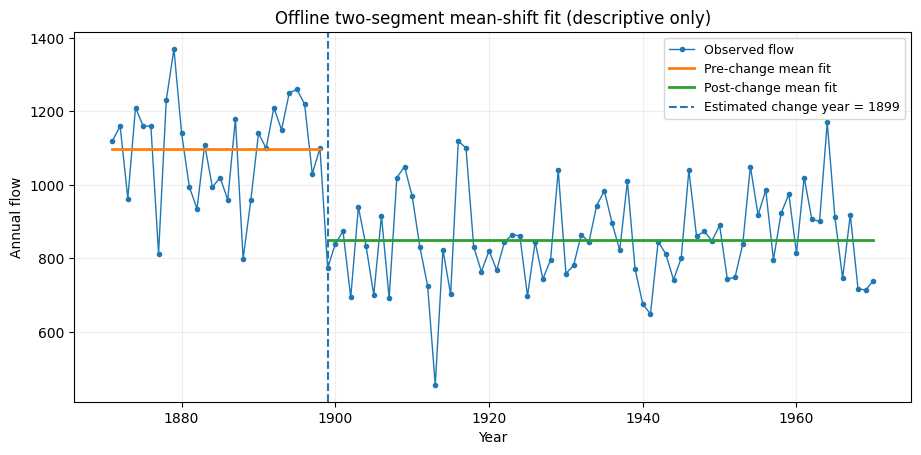

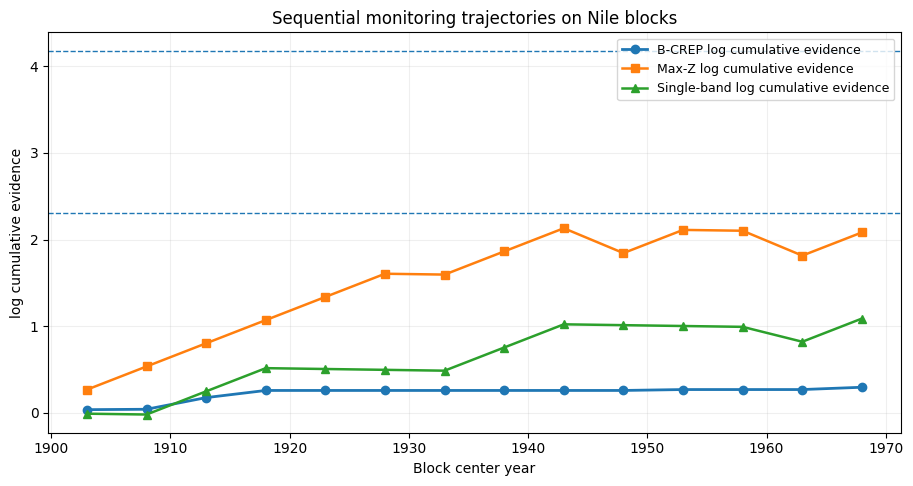

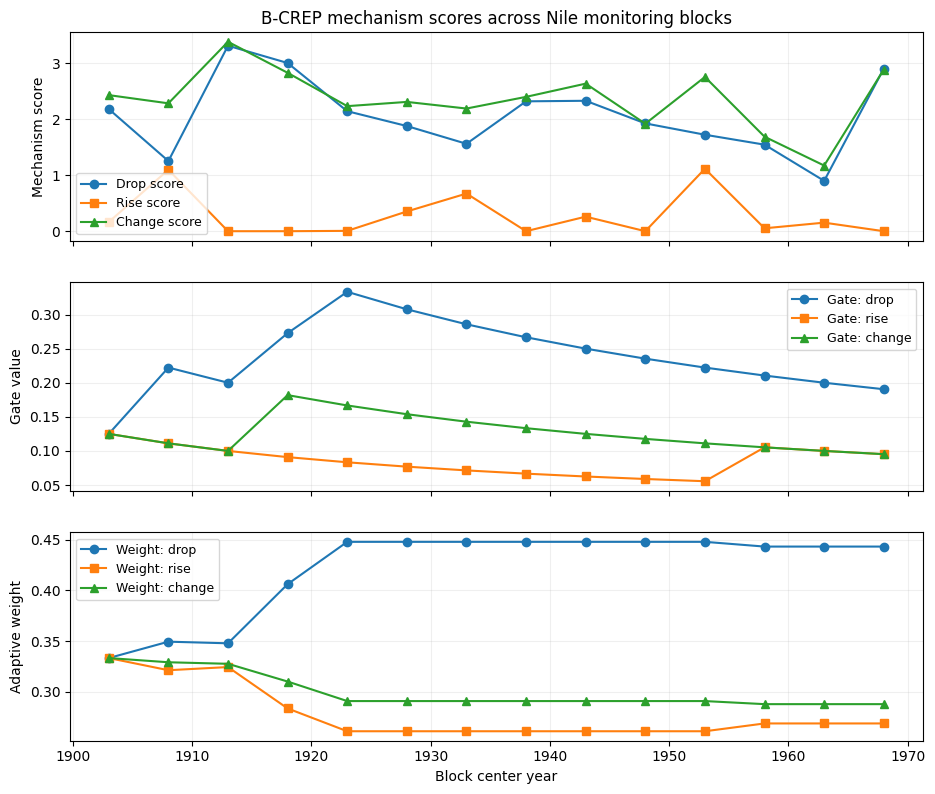

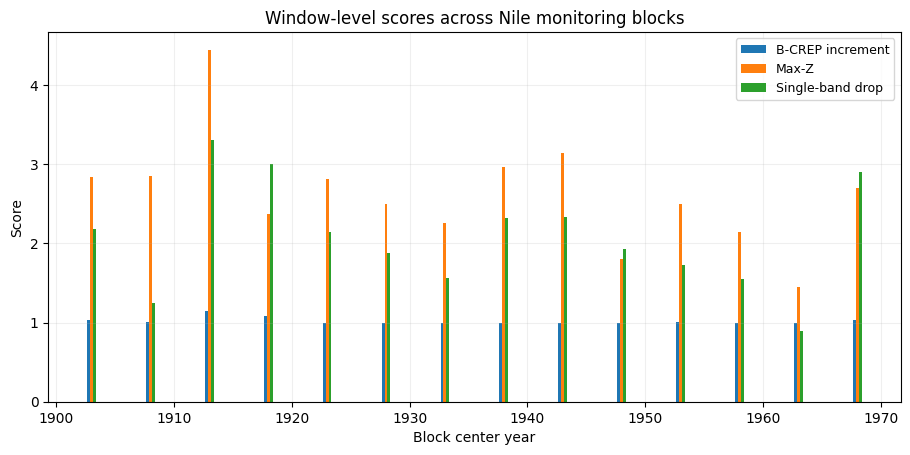

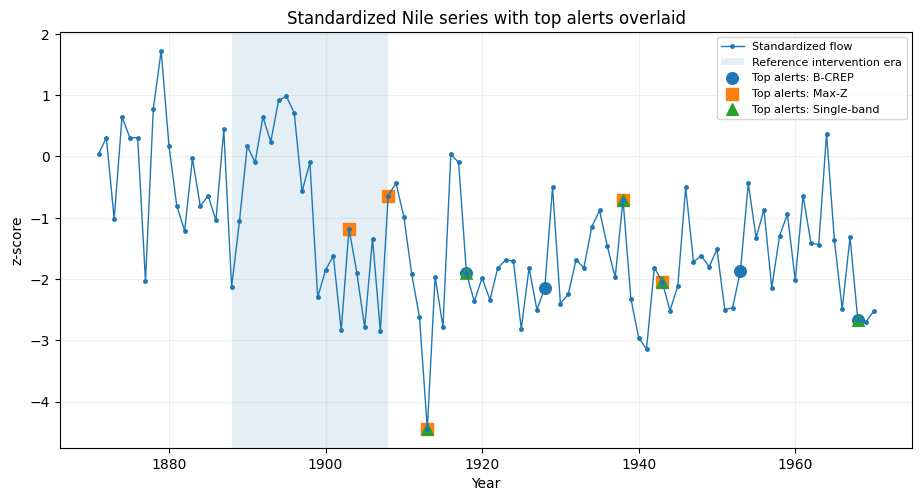

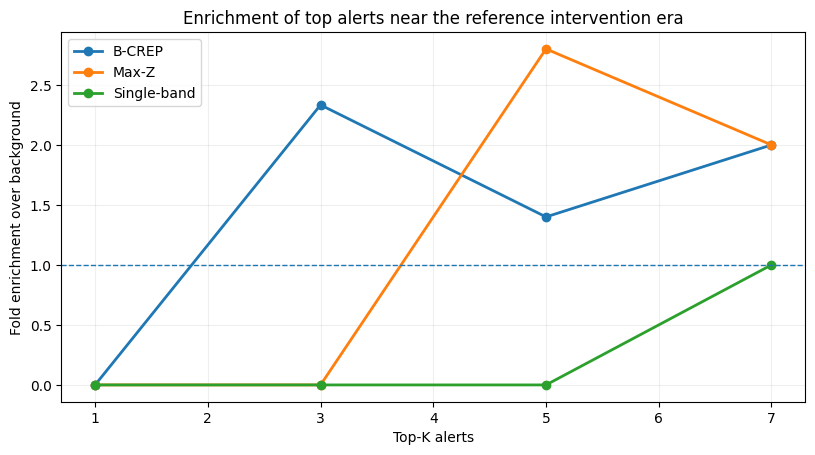

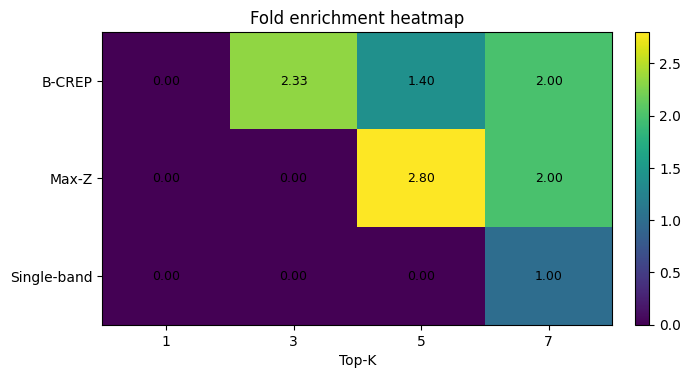

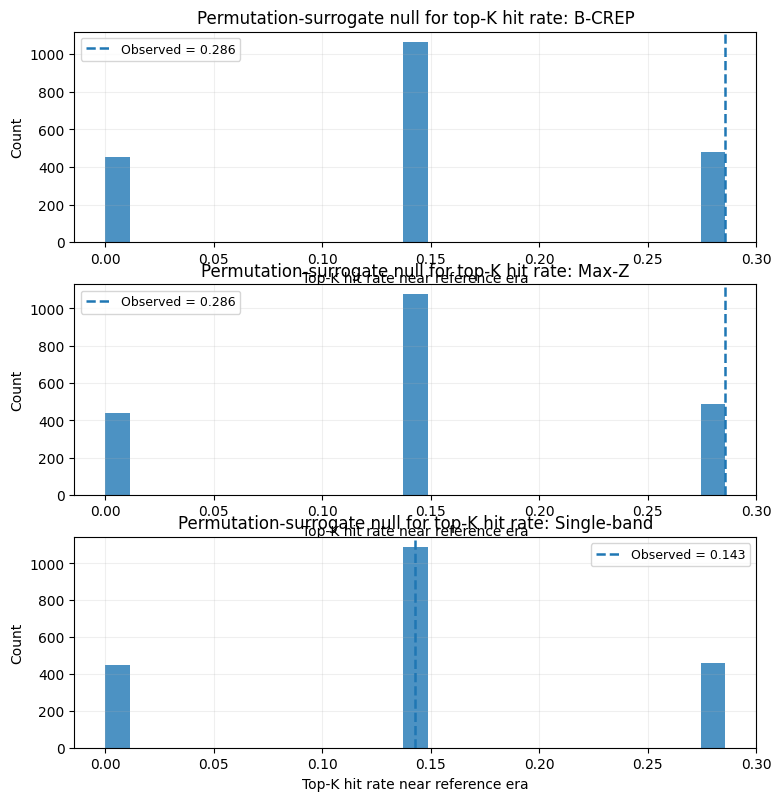

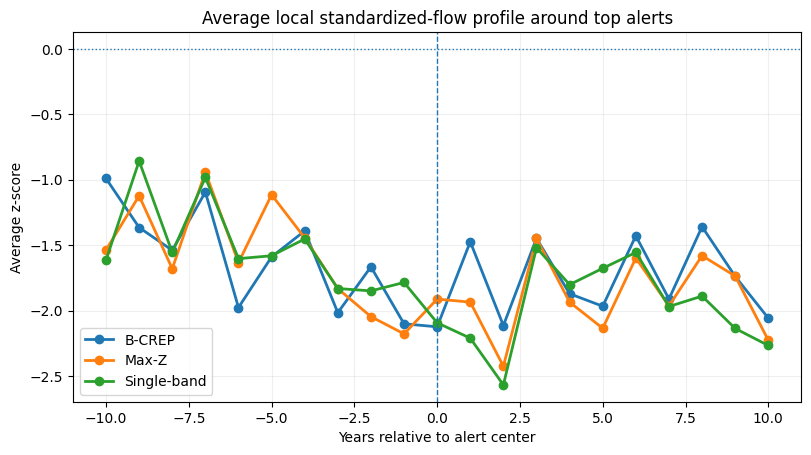


Results folder: /content/bcrep_nile_realdata_results
ZIP archive   : /content/bcrep_nile_realdata_results.zip

Done.


In [3]:
# ============================================================
# B-CREP real-data application for Nile River annual flow
# Colab-ready, self-contained, saves all plots/tables to ZIP
# ------------------------------------------------------------
# Purpose
#   Apply a practical Bayesian CREP-style monitor (B-CREP) to the
#   classic Nile River annual flow series, aligned with the paper's
#   CREP-B setup: calibration on 1871--1900, monitoring on 1901--1970,
#   and disjoint 5-year blocks.
#
# What this script does
#   1) loads the Nile dataset from statsmodels;
#   2) standardizes flows using calibration-only robust center/scale;
#   3) builds disjoint 5-year blocks;
#   4) runs a practical B-CREP monitor with mechanism-adaptive Bayesian
#      predictive e-merging;
#   5) compares against weak benchmarks:
#        - Max-Z (naive max standardized residual),
#        - Single-band drop score (naive one-sided level-shift rule);
#   6) produces real-data utility diagnostics:
#        - top-alert ranking,
#        - enrichment near a reference intervention era,
#        - temporal concentration near the reference change year,
#        - permutation-surrogate significance for alert enrichment,
#        - average local profiles around top alerts;
#   7) saves all plots/tables, shows them inline, and creates a ZIP.
#
# Honest note
#   This is a practical application proxy of Methodology Part II,
#   not a full MCMC/horseshoe implementation. The Bayesian component
#   enters through posterior-predictive Student-t nulls, Beta-Bernoulli
#   gating, adaptive e-merging, and sequential predictive updating.
# ============================================================

import os
import sys
import json
import math
import shutil
import warnings
from dataclasses import dataclass

warnings.filterwarnings("ignore")

# -----------------------------
# Colab-friendly imports / installs
# -----------------------------
def maybe_install(package: str):
    try:
        __import__(package.split("==")[0].split(">=")[0])
    except Exception:
        import subprocess
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

maybe_install("statsmodels>=0.14")
maybe_install("openpyxl>=3.1")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from scipy import stats
import statsmodels.api as sm

# -----------------------------
# Configuration
# -----------------------------
SEED = 20260324
rng = np.random.default_rng(SEED)

RESULTS_DIR = "/content/bcrep_nile_realdata_results"
os.makedirs(RESULTS_DIR, exist_ok=True)
TABLE_DIR = os.path.join(RESULTS_DIR, "tables")
FIG_DIR = os.path.join(RESULTS_DIR, "figures")
os.makedirs(TABLE_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

CONFIG = {
    "dataset_name": "Nile River annual flow",
    "dataset_units": "10^8 m^3",
    "calibration_start_year": 1871,
    "calibration_end_year": 1900,
    "monitoring_start_year": 1901,
    "monitoring_end_year": 1970,
    "block_size_years": 5,
    "reference_change_year": 1898,
    "reference_halfwidth_years": 10,
    "topk_grid": [1, 3, 5, 7],
    "topk_alerts": 7,
    "profile_halfwidth_years": 10,
    "perm_reps": 2000,
    "lambda_benchmark": 0.60,
    "beta_a0": 1.0,
    "beta_b0": 7.0,
    "mech_names": ["drop", "rise", "change"],
    "alt_shift_drop": 1.50,
    "alt_shift_rise": 1.25,
    "alt_shift_change": 1.35,
    "e_cap": 30.0,
    "e_floor": 1e-4,
}
with open(os.path.join(RESULTS_DIR, "config.json"), "w") as f:
    json.dump(CONFIG, f, indent=2)

# -----------------------------
# Helpers
# -----------------------------
def save_df(df: pd.DataFrame, name: str):
    csv_path = os.path.join(TABLE_DIR, f"{name}.csv")
    xlsx_path = os.path.join(TABLE_DIR, f"{name}.xlsx")
    df.to_csv(csv_path, index=False)
    try:
        df.to_excel(xlsx_path, index=False)
    except Exception:
        pass
    print(f"\n{name}:")
    display(df)
    return csv_path


def save_fig(fig, name: str, dpi: int = 180):
    path = os.path.join(FIG_DIR, f"{name}.png")
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    return path


def robust_mad(x):
    x = np.asarray(x, dtype=float)
    med = np.nanmedian(x)
    mad = np.nanmedian(np.abs(x - med))
    return 1.4826 * mad + 1e-12


def robust_z(x, center=None, scale=None):
    x = np.asarray(x, dtype=float)
    if center is None:
        center = np.nanmedian(x)
    if scale is None:
        scale = robust_mad(x)
    return (x - center) / (scale + 1e-12)


def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -30, 30)))


def softmax(logw):
    a = np.asarray(logw, dtype=float)
    a = a - np.max(a)
    w = np.exp(a)
    return w / np.sum(w)


def t_pdf(x, df, loc, scale):
    scale = max(float(scale), 1e-8)
    return stats.t.pdf(x, df=max(df, 2.1), loc=loc, scale=scale)


def empirical_p_from_calibration(stat, cal_stats):
    cal_stats = np.asarray(cal_stats, dtype=float)
    return (1.0 + np.sum(cal_stats >= stat)) / (len(cal_stats) + 1.0)


def e_from_p(p, lam=0.60):
    p = float(np.clip(p, 1e-12, 1.0))
    return lam * (p ** (lam - 1.0))

# -----------------------------
# Bayesian predictive pieces
# -----------------------------
@dataclass
class NIGState:
    kappa: float
    mu: float
    alpha: float
    beta: float


def nig_from_data(x, mu0=None, kappa0=1.0, alpha0=2.0, beta0=None):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        if mu0 is None:
            mu0 = 0.0
        if beta0 is None:
            beta0 = 1.0
        return NIGState(float(kappa0), float(mu0), float(alpha0), float(beta0))

    if mu0 is None:
        mu0 = float(np.median(x))
    if beta0 is None:
        beta0 = float(np.var(x, ddof=1) + 1.0)
    n = len(x)
    xbar = float(np.mean(x))
    ss = float(np.sum((x - xbar) ** 2))
    kappa_n = kappa0 + n
    mu_n = (kappa0 * mu0 + n * xbar) / kappa_n
    alpha_n = alpha0 + 0.5 * n
    beta_n = beta0 + 0.5 * ss + (kappa0 * n * (xbar - mu0) ** 2) / (2.0 * kappa_n)
    return NIGState(float(kappa_n), float(mu_n), float(alpha_n), float(beta_n))


def nig_update(state: NIGState, x: float) -> NIGState:
    kappa_n = state.kappa + 1.0
    mu_n = (state.kappa * state.mu + x) / kappa_n
    alpha_n = state.alpha + 0.5
    beta_n = state.beta + 0.5 * (state.kappa * (x - state.mu) ** 2) / kappa_n
    return NIGState(float(kappa_n), float(mu_n), float(alpha_n), float(beta_n))


def nig_pred_params(state: NIGState):
    df = 2.0 * state.alpha
    scale = math.sqrt(state.beta * (state.kappa + 1.0) / (state.alpha * state.kappa))
    return df, state.mu, scale


def t_quantile_from_state(state: NIGState, q: float):
    df, loc, scale = nig_pred_params(state)
    return stats.t.ppf(q, df=max(df, 2.1), loc=loc, scale=max(scale, 1e-8))

# -----------------------------
# Data loading / preprocessing
# -----------------------------
def load_nile_data():
    print("Loading Nile dataset from statsmodels ...")
    ds = sm.datasets.nile.load_pandas().data.copy()
    ds.columns = [c.lower() for c in ds.columns]
    if "volume" in ds.columns:
        flow_col = "volume"
    elif "x" in ds.columns:
        flow_col = "x"
    else:
        flow_col = ds.columns[-1]
    df = pd.DataFrame({
        "year": ds["year"].astype(int),
        "flow": ds[flow_col].astype(float),
    })
    return df


def estimate_offline_mean_shift_year(years, values, min_seg=10):
    years = np.asarray(years)
    values = np.asarray(values, dtype=float)
    best = None
    for k in range(min_seg, len(values) - min_seg):
        left = values[:k]
        right = values[k:]
        rss = np.sum((left - left.mean()) ** 2) + np.sum((right - right.mean()) ** 2)
        if best is None or rss < best[0]:
            best = (rss, k, years[k - 1], years[k])
    rss, k, left_year, right_year = best
    cp_year = int(right_year)
    return {
        "estimated_change_year": cp_year,
        "left_segment_end_year": int(left_year),
        "right_segment_start_year": int(right_year),
        "rss": float(rss),
    }


def build_blocks(df: pd.DataFrame, start_year: int, end_year: int, block_size: int):
    sub = df[(df["year"] >= start_year) & (df["year"] <= end_year)].copy().reset_index(drop=True)
    blocks = []
    for start_idx in range(0, len(sub), block_size):
        blk = sub.iloc[start_idx:start_idx + block_size].copy()
        if len(blk) < block_size:
            continue
        years = blk["year"].to_numpy()
        flows = blk["flow"].to_numpy()
        z = blk["z"].to_numpy()
        x = np.arange(len(blk), dtype=float)
        slope = np.polyfit(x, z, deg=1)[0] if len(blk) >= 2 else 0.0
        half = len(blk) // 2
        early_mean = float(np.mean(z[:half])) if half > 0 else float(np.mean(z))
        late_mean = float(np.mean(z[half:])) if half > 0 else float(np.mean(z))
        mean_z = float(np.mean(z))
        std_z = float(np.std(z, ddof=1)) if len(z) > 1 else 0.0
        maxz = float(np.max(np.abs(z)))
        drop = max(0.0, -mean_z) + 0.80 * max(0.0, -slope) + 0.60 * max(0.0, early_mean - late_mean)
        rise = max(0.0, mean_z) + 0.80 * max(0.0, slope) + 0.60 * max(0.0, late_mean - early_mean)
        change = abs(mean_z) + 0.65 * abs(slope) + 0.45 * abs(late_mean - early_mean) + 0.20 * std_z
        blocks.append({
            "start_idx": int(blk.index[0]),
            "end_idx": int(blk.index[-1]),
            "start_year": int(years[0]),
            "end_year": int(years[-1]),
            "center_year": float(np.mean(years)),
            "n_points": int(len(blk)),
            "flow_mean": float(np.mean(flows)),
            "flow_min": float(np.min(flows)),
            "flow_max": float(np.max(flows)),
            "mean_z": mean_z,
            "std_z": std_z,
            "slope_z": float(slope),
            "early_mean_z": early_mean,
            "late_mean_z": late_mean,
            "drop": float(drop),
            "rise": float(rise),
            "change": float(change),
            "maxz": float(maxz),
            "years_list": years.tolist(),
            "z_list": z.tolist(),
            "flow_list": flows.tolist(),
        })
    return pd.DataFrame(blocks)

# -----------------------------
# B-CREP monitor for Nile blocks
# -----------------------------
def run_bcrep_monitor(cal_blocks: pd.DataFrame, mon_blocks: pd.DataFrame):
    alt_shift = {
        "drop": CONFIG["alt_shift_drop"],
        "rise": CONFIG["alt_shift_rise"],
        "change": CONFIG["alt_shift_change"],
    }
    mech_names = CONFIG["mech_names"]

    # Fit predictive states on log1p(score) from calibration blocks.
    states = {}
    beta_counts = {}
    cum_log_support = {m: 0.0 for m in mech_names}
    for m in mech_names:
        y0 = np.log1p(cal_blocks[m].to_numpy())
        states[m] = nig_from_data(y0, mu0=float(np.median(y0)), kappa0=1.0, alpha0=2.0, beta0=float(np.var(y0, ddof=1) + 1.0))
        beta_counts[m] = {"a": float(CONFIG["beta_a0"]), "b": float(CONFIG["beta_b0"])}

    rows = []
    cumE = 1.0
    for i, row in mon_blocks.iterrows():
        score_y = {m: float(np.log1p(row[m])) for m in mech_names}
        mech_info = {}

        for m in mech_names:
            state = states[m]
            df0, loc0, scale0 = nig_pred_params(state)
            shift = alt_shift[m] * max(scale0, 0.15)
            g0 = t_pdf(score_y[m], df0, loc0, scale0)
            g1 = t_pdf(score_y[m], max(df0, 3.0), loc0 + shift, 1.10 * scale0)
            ratio = float((g1 + 1e-15) / (g0 + 1e-15))

            # Predictable gate: posterior mean of anomaly probability based on exceedance.
            q80 = t_quantile_from_state(state, 0.80)
            success = 1.0 if score_y[m] > q80 else 0.0
            a, b = beta_counts[m]["a"], beta_counts[m]["b"]
            gate = (a) / (a + b)
            # stabilized gated increment
            e_mech = 1.0 + gate * max(0.0, ratio - 1.0)
            e_mech = float(np.clip(e_mech, CONFIG["e_floor"], CONFIG["e_cap"]))

            mech_info[m] = {
                "score_log": score_y[m],
                "g0": g0,
                "g1": g1,
                "ratio": ratio,
                "gate": gate,
                "e_mech": e_mech,
                "q80": q80,
                "success": success,
            }

        weights = softmax([cum_log_support[m] for m in mech_names])
        w_map = {m: float(weights[j]) for j, m in enumerate(mech_names)}
        inc = sum(w_map[m] * mech_info[m]["e_mech"] for m in mech_names)
        inc = float(np.clip(inc, CONFIG["e_floor"], CONFIG["e_cap"]))
        cumE *= inc

        rows.append({
            "block_index": int(i + 1),
            "start_year": int(row["start_year"]),
            "end_year": int(row["end_year"]),
            "center_year": float(row["center_year"]),
            "drop": float(row["drop"]),
            "rise": float(row["rise"]),
            "change": float(row["change"]),
            "maxz": float(row["maxz"]),
            "bcrep_increment": inc,
            "bcrep_cumE": cumE,
            "w_drop": w_map["drop"],
            "w_rise": w_map["rise"],
            "w_change": w_map["change"],
            "gate_drop": mech_info["drop"]["gate"],
            "gate_rise": mech_info["rise"]["gate"],
            "gate_change": mech_info["change"]["gate"],
            "ratio_drop": mech_info["drop"]["ratio"],
            "ratio_rise": mech_info["rise"]["ratio"],
            "ratio_change": mech_info["change"]["ratio"],
        })

        for m in mech_names:
            # Update posterior support and predictive state after scoring the block.
            cum_log_support[m] += math.log(max(mech_info[m]["e_mech"], 1e-12))
            beta_counts[m]["a"] += mech_info[m]["success"]
            beta_counts[m]["b"] += (1.0 - mech_info[m]["success"])
            states[m] = nig_update(states[m], score_y[m])

    return pd.DataFrame(rows)

# -----------------------------
# Benchmarks and utility diagnostics
# -----------------------------
def add_benchmark_evidence(cal_blocks: pd.DataFrame, mon_blocks: pd.DataFrame):
    cal_maxz = cal_blocks["maxz"].to_numpy()
    cal_drop = cal_blocks["drop"].to_numpy()
    out = mon_blocks.copy()

    maxz_p = [empirical_p_from_calibration(v, cal_maxz) for v in out["maxz"].to_numpy()]
    drop_p = [empirical_p_from_calibration(v, cal_drop) for v in out["drop"].to_numpy()]
    out["maxz_p"] = maxz_p
    out["singleband_p"] = drop_p
    out["maxz_e"] = [e_from_p(p, CONFIG["lambda_benchmark"]) for p in maxz_p]
    out["singleband_e"] = [e_from_p(p, CONFIG["lambda_benchmark"]) for p in drop_p]
    out["maxz_cumE"] = np.cumprod(out["maxz_e"].to_numpy())
    out["singleband_cumE"] = np.cumprod(out["singleband_e"].to_numpy())
    return out


def annotate_reference(df_blocks: pd.DataFrame, ref_year: int, halfwidth: int):
    out = df_blocks.copy()
    out["year_dist"] = out["center_year"] - ref_year
    out["year_abs"] = np.abs(out["year_dist"])
    out["near_reference_era"] = out["year_abs"] <= halfwidth
    return out


def make_top_alert_table(df_blocks: pd.DataFrame):
    parts = []
    for method, score_col, topk in [
        ("B-CREP", "bcrep_increment", 7),
        ("Max-Z", "maxz", 5),
        ("Single-band", "drop", 5),
    ]:
        tmp = df_blocks.sort_values(score_col, ascending=False).head(topk).copy()
        tmp.insert(0, "method", method)
        tmp.insert(1, "rank", np.arange(1, len(tmp) + 1))
        tmp.insert(2, "score_name", score_col)
        tmp.insert(3, "score_value", tmp[score_col].to_numpy())
        keep = [
            "method", "rank", "center_year", "score_name", "score_value",
            "near_reference_era", "year_abs", "bcrep_increment", "bcrep_cumE",
            "maxz", "drop", "rise", "change"
        ]
        parts.append(tmp[keep])
    return pd.concat(parts, axis=0, ignore_index=True)


def enrichment_table(df_blocks: pd.DataFrame, method_cols, topk_grid):
    rows = []
    background_rate = float(df_blocks["near_reference_era"].mean())
    for method_name, score_col in method_cols.items():
        ranked = df_blocks.sort_values(score_col, ascending=False).reset_index(drop=True)
        for k in topk_grid:
            top = ranked.head(k).copy()
            hit_rate = float(top["near_reference_era"].mean())
            fold = hit_rate / background_rate if background_rate > 0 else np.nan
            rows.append({
                "method": method_name,
                "topk": int(k),
                "hit_rate": hit_rate,
                "background_rate": background_rate,
                "fold_enrichment": fold,
                "mean_abs_year_distance": float(top["year_abs"].mean()),
                "median_abs_year_distance": float(top["year_abs"].median()),
            })
    return pd.DataFrame(rows)


def temporal_concentration_table(df_blocks: pd.DataFrame, method_cols, topk=5):
    rows = []
    for method_name, score_col in method_cols.items():
        top = df_blocks.sort_values(score_col, ascending=False).head(topk).copy()
        center_year_mean = float(top["center_year"].mean())
        rows.append({
            "method": method_name,
            "topk": int(topk),
            "mean_abs_year_distance": float(top["year_abs"].mean()),
            "median_abs_year_distance": float(top["year_abs"].median()),
            "fraction_near_reference_era": float(top["near_reference_era"].mean()),
            "mean_center_year": center_year_mean,
            "sd_center_year": float(top["center_year"].std(ddof=1)) if len(top) > 1 else 0.0,
        })
    return pd.DataFrame(rows)


def permutation_surrogate_enrichment(df_blocks: pd.DataFrame, method_cols, topk=5, reps=2000, seed=20260324):
    r = np.random.default_rng(seed)
    years = df_blocks["center_year"].to_numpy().copy()
    near = df_blocks["near_reference_era"].to_numpy().copy()
    observed = {}
    surrogates = {m: [] for m in method_cols}

    for method_name, score_col in method_cols.items():
        order = np.argsort(-df_blocks[score_col].to_numpy())
        obs_near = near[order][:topk]
        observed[method_name] = float(np.mean(obs_near))

    for rep in range(reps):
        perm = r.permutation(len(df_blocks))
        near_perm = near[perm]
        for method_name, score_col in method_cols.items():
            order = np.argsort(-df_blocks[score_col].to_numpy())
            hit = float(np.mean(near_perm[order][:topk]))
            surrogates[method_name].append(hit)

    rows = []
    for method_name in method_cols:
        s = np.asarray(surrogates[method_name], dtype=float)
        obs = observed[method_name]
        p_emp = (1.0 + np.sum(s >= obs)) / (len(s) + 1.0)
        rows.append({
            "method": method_name,
            "topk": int(topk),
            "observed_hit_rate": obs,
            "surrogate_mean": float(np.mean(s)),
            "surrogate_sd": float(np.std(s, ddof=1)),
            "surrogate_q95": float(np.quantile(s, 0.95)),
            "surrogate_q99": float(np.quantile(s, 0.99)),
            "empirical_p_value": float(p_emp),
        })
    return pd.DataFrame(rows), surrogates


def average_profiles(df_year: pd.DataFrame, df_blocks: pd.DataFrame, method_cols, topk=5, halfwidth=10):
    rows = []
    profile_store = {}
    year_to_z = {int(y): float(z) for y, z in zip(df_year["year"], df_year["z"])}
    offsets = np.arange(-halfwidth, halfwidth + 1)

    for method_name, score_col in method_cols.items():
        top = df_blocks.sort_values(score_col, ascending=False).head(topk).copy()
        mats = []
        for cy in top["center_year"].round().astype(int):
            prof = []
            for off in offsets:
                prof.append(year_to_z.get(int(cy + off), np.nan))
            mats.append(prof)
        mat = np.asarray(mats, dtype=float)
        mean_prof = np.nanmean(mat, axis=0)
        profile_store[method_name] = (offsets.copy(), mean_prof.copy())
        center_idx = np.where(offsets == 0)[0][0]
        rows.append({
            "method": method_name,
            "topk": int(topk),
            "min_mean_profile": float(np.nanmin(mean_prof)),
            "max_mean_profile": float(np.nanmax(mean_prof)),
            "mean_center_value": float(mean_prof[center_idx]),
        })

    return pd.DataFrame(rows), profile_store

# -----------------------------
# Plotting
# -----------------------------
def plot_series_split(df, calib_end_year, ref_year, est_year):
    fig, ax = plt.subplots(figsize=(11, 4.8))
    ax.plot(df["year"], df["flow"], marker="o", linewidth=1.2, markersize=3)
    ax.axvspan(df["year"].min(), calib_end_year, alpha=0.12, label="Calibration")
    ax.axvspan(calib_end_year + 1, df["year"].max(), alpha=0.07, label="Monitoring")
    ax.axvline(ref_year, linestyle="--", linewidth=1.5, label=f"Reference year = {ref_year}")
    ax.axvline(est_year, linestyle=":", linewidth=1.7, label=f"Offline mean-shift estimate = {est_year}")
    ax.set_title("Nile annual flow with calibration / monitoring split")
    ax.set_xlabel("Year")
    ax.set_ylabel("Annual flow")
    ax.legend(loc="best", fontsize=9)
    ax.grid(alpha=0.2)
    return save_fig(fig, "nile_series_split")


def plot_z_all(df, calib_end_year, ref_year):
    fig, ax = plt.subplots(figsize=(11, 4.8))
    ax.plot(df["year"], df["z"], marker="o", linewidth=1.2, markersize=3)
    ax.axhline(0.0, color="black", linewidth=0.9)
    ax.axvspan(df["year"].min(), calib_end_year, alpha=0.12)
    ax.axvline(ref_year, linestyle="--", linewidth=1.4)
    ax.set_title("Robustly standardized Nile flow series")
    ax.set_xlabel("Year")
    ax.set_ylabel("z-score (calibration-only median/MAD)")
    ax.grid(alpha=0.2)
    return save_fig(fig, "nile_z_all")


def plot_offline_scan(df, cp_year):
    years = df["year"].to_numpy()
    y = df["flow"].to_numpy()
    idx = np.where(years == cp_year)[0][0]
    left_mean = np.mean(y[:idx])
    right_mean = np.mean(y[idx:])
    fig, ax = plt.subplots(figsize=(10.8, 4.8))
    ax.plot(years, y, marker="o", linewidth=1.0, markersize=3, label="Observed flow")
    ax.plot(years[:idx], np.repeat(left_mean, idx), linewidth=2.0, label="Pre-change mean fit")
    ax.plot(years[idx:], np.repeat(right_mean, len(y) - idx), linewidth=2.0, label="Post-change mean fit")
    ax.axvline(cp_year, linestyle="--", linewidth=1.5, label=f"Estimated change year = {cp_year}")
    ax.set_title("Offline two-segment mean-shift fit (descriptive only)")
    ax.set_xlabel("Year")
    ax.set_ylabel("Annual flow")
    ax.legend(loc="best", fontsize=9)
    ax.grid(alpha=0.2)
    return save_fig(fig, "offline_mean_shift_fit")


def plot_monitoring_trajectories(mon):
    fig, ax = plt.subplots(figsize=(11, 5.2))
    ax.plot(mon["center_year"], np.log(mon["bcrep_cumE"]), marker="o", linewidth=2.0, label="B-CREP log cumulative evidence")
    ax.plot(mon["center_year"], np.log(mon["maxz_cumE"]), marker="s", linewidth=1.8, label="Max-Z log cumulative evidence")
    ax.plot(mon["center_year"], np.log(mon["singleband_cumE"]), marker="^", linewidth=1.8, label="Single-band log cumulative evidence")
    for tau in [10.0, 65.45]:
        ax.axhline(np.log(tau), linestyle="--", linewidth=1.0)
    ax.set_title("Sequential monitoring trajectories on Nile blocks")
    ax.set_xlabel("Block center year")
    ax.set_ylabel("log cumulative evidence")
    ax.legend(loc="best", fontsize=9)
    ax.grid(alpha=0.2)
    return save_fig(fig, "monitoring_trajectories")


def plot_internal(mon):
    fig, axs = plt.subplots(3, 1, figsize=(11, 9.2), sharex=True)
    axs[0].plot(mon["center_year"], mon["drop"], marker="o", linewidth=1.5, label="Drop score")
    axs[0].plot(mon["center_year"], mon["rise"], marker="s", linewidth=1.5, label="Rise score")
    axs[0].plot(mon["center_year"], mon["change"], marker="^", linewidth=1.5, label="Change score")
    axs[0].set_ylabel("Mechanism score")
    axs[0].set_title("B-CREP mechanism scores across Nile monitoring blocks")
    axs[0].legend(loc="best", fontsize=9)
    axs[0].grid(alpha=0.2)

    axs[1].plot(mon["center_year"], mon["gate_drop"], marker="o", linewidth=1.5, label="Gate: drop")
    axs[1].plot(mon["center_year"], mon["gate_rise"], marker="s", linewidth=1.5, label="Gate: rise")
    axs[1].plot(mon["center_year"], mon["gate_change"], marker="^", linewidth=1.5, label="Gate: change")
    axs[1].set_ylabel("Gate value")
    axs[1].legend(loc="best", fontsize=9)
    axs[1].grid(alpha=0.2)

    axs[2].plot(mon["center_year"], mon["w_drop"], marker="o", linewidth=1.5, label="Weight: drop")
    axs[2].plot(mon["center_year"], mon["w_rise"], marker="s", linewidth=1.5, label="Weight: rise")
    axs[2].plot(mon["center_year"], mon["w_change"], marker="^", linewidth=1.5, label="Weight: change")
    axs[2].set_xlabel("Block center year")
    axs[2].set_ylabel("Adaptive weight")
    axs[2].legend(loc="best", fontsize=9)
    axs[2].grid(alpha=0.2)
    return save_fig(fig, "bcrep_mechanisms_weights_gates")


def plot_alert_overlay(df_year, mon, top_table, ref_year, halfwidth):
    fig, ax = plt.subplots(figsize=(11, 5.4))
    ax.plot(df_year["year"], df_year["z"], marker="o", linewidth=1.0, markersize=2.5, label="Standardized flow")
    ax.axvspan(ref_year - halfwidth, ref_year + halfwidth, alpha=0.12, label="Reference intervention era")

    for method, marker in [("B-CREP", "o"), ("Max-Z", "s"), ("Single-band", "^")]:
        sub = top_table[top_table["method"] == method].copy()
        yvals = np.interp(sub["center_year"], df_year["year"], df_year["z"])
        ax.scatter(sub["center_year"], yvals, marker=marker, s=70, label=f"Top alerts: {method}")

    ax.set_title("Standardized Nile series with top alerts overlaid")
    ax.set_xlabel("Year")
    ax.set_ylabel("z-score")
    ax.legend(loc="best", fontsize=8)
    ax.grid(alpha=0.2)
    return save_fig(fig, "detrended_monitoring_with_alerts")


def plot_enrichment_curves(enrich_df):
    fig, ax = plt.subplots(figsize=(9.6, 4.8))
    for method in enrich_df["method"].unique():
        sub = enrich_df[enrich_df["method"] == method].sort_values("topk")
        ax.plot(sub["topk"], sub["fold_enrichment"], marker="o", linewidth=2, label=method)
    ax.axhline(1.0, linestyle="--", linewidth=1.0)
    ax.set_title("Enrichment of top alerts near the reference intervention era")
    ax.set_xlabel("Top-K alerts")
    ax.set_ylabel("Fold enrichment over background")
    ax.legend(loc="best")
    ax.grid(alpha=0.2)
    p1 = save_fig(fig, "alert_enrichment_curves")

    pivot = enrich_df.pivot(index="method", columns="topk", values="fold_enrichment")
    fig2, ax2 = plt.subplots(figsize=(7.2, 3.8))
    im = ax2.imshow(pivot.values, aspect="auto")
    ax2.set_xticks(np.arange(len(pivot.columns)))
    ax2.set_xticklabels(pivot.columns)
    ax2.set_yticks(np.arange(len(pivot.index)))
    ax2.set_yticklabels(pivot.index)
    ax2.set_xlabel("Top-K")
    ax2.set_title("Fold enrichment heatmap")
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            ax2.text(j, i, f"{pivot.values[i, j]:.2f}", ha="center", va="center", fontsize=9)
    fig2.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)
    p2 = save_fig(fig2, "fold_enrichment_heatmap")
    return p1, p2


def plot_surrogate_histograms(surrogates, surrogate_df):
    methods = list(surrogates.keys())
    fig, axs = plt.subplots(len(methods), 1, figsize=(8.8, 3.1 * len(methods)), sharex=False)
    if len(methods) == 1:
        axs = [axs]
    for ax, method in zip(axs, methods):
        vals = np.asarray(surrogates[method], dtype=float)
        ax.hist(vals, bins=min(25, max(8, int(np.sqrt(len(vals))))), alpha=0.8)
        obs = float(surrogate_df.loc[surrogate_df["method"] == method, "observed_hit_rate"].iloc[0])
        ax.axvline(obs, linestyle="--", linewidth=1.8, label=f"Observed = {obs:.3f}")
        ax.set_title(f"Permutation-surrogate null for top-K hit rate: {method}")
        ax.set_xlabel("Top-K hit rate near reference era")
        ax.set_ylabel("Count")
        ax.legend(loc="best", fontsize=9)
        ax.grid(alpha=0.2)
    return save_fig(fig, "surrogate_histograms")


def plot_average_profiles(profile_store):
    fig, ax = plt.subplots(figsize=(9.4, 4.8))
    for method, (offsets, profile) in profile_store.items():
        ax.plot(offsets, profile, marker="o", linewidth=2, label=method)
    ax.axvline(0, linestyle="--", linewidth=1.0)
    ax.axhline(0, linestyle=":", linewidth=1.0)
    ax.set_title("Average local standardized-flow profile around top alerts")
    ax.set_xlabel("Years relative to alert center")
    ax.set_ylabel("Average z-score")
    ax.legend(loc="best")
    ax.grid(alpha=0.2)
    return save_fig(fig, "average_profiles_top_alerts")


def plot_block_bar_summary(mon):
    fig, ax = plt.subplots(figsize=(11, 4.8))
    ax.bar(mon["center_year"] - 0.25, mon["bcrep_increment"], width=0.25, label="B-CREP increment")
    ax.bar(mon["center_year"], mon["maxz"], width=0.25, label="Max-Z")
    ax.bar(mon["center_year"] + 0.25, mon["drop"], width=0.25, label="Single-band drop")
    ax.set_title("Window-level scores across Nile monitoring blocks")
    ax.set_xlabel("Block center year")
    ax.set_ylabel("Score")
    ax.legend(loc="best", fontsize=9)
    ax.grid(alpha=0.2)
    return save_fig(fig, "window_level_score_bars")

# -----------------------------
# Main
# -----------------------------
print("Loading and preprocessing Nile data ...")
df = load_nile_data()
offline_cp = estimate_offline_mean_shift_year(df["year"].to_numpy(), df["flow"].to_numpy())

cal_mask = (df["year"] >= CONFIG["calibration_start_year"]) & (df["year"] <= CONFIG["calibration_end_year"])
cal_flow = df.loc[cal_mask, "flow"].to_numpy()
rob_center = float(np.median(cal_flow))
rob_scale = float(robust_mad(cal_flow))
df["z"] = robust_z(df["flow"].to_numpy(), center=rob_center, scale=rob_scale)

preprocess_summary = pd.DataFrame([{
    "dataset": CONFIG["dataset_name"],
    "units": CONFIG["dataset_units"],
    "n_points": int(len(df)),
    "year_min": int(df["year"].min()),
    "year_max": int(df["year"].max()),
    "calibration_start_year": CONFIG["calibration_start_year"],
    "calibration_end_year": CONFIG["calibration_end_year"],
    "monitoring_start_year": CONFIG["monitoring_start_year"],
    "monitoring_end_year": CONFIG["monitoring_end_year"],
    "block_size_years": CONFIG["block_size_years"],
    "robust_center_median": rob_center,
    "robust_scale_mad": rob_scale,
}])
save_df(preprocess_summary, "preprocessing_summary")

reference_summary = pd.DataFrame([{
    "reference_change_year": CONFIG["reference_change_year"],
    "reference_halfwidth_years": CONFIG["reference_halfwidth_years"],
    "offline_estimated_change_year": offline_cp["estimated_change_year"],
    "left_segment_end_year": offline_cp["left_segment_end_year"],
    "right_segment_start_year": offline_cp["right_segment_start_year"],
    "offline_rss": offline_cp["rss"],
}])
save_df(reference_summary, "reference_change_summary")

block_size = CONFIG["block_size_years"]
cal_blocks = build_blocks(df, CONFIG["calibration_start_year"], CONFIG["calibration_end_year"], block_size)
mon_blocks = build_blocks(df, CONFIG["monitoring_start_year"], CONFIG["monitoring_end_year"], block_size)

print("\nRunning B-CREP monitoring on disjoint 5-year Nile blocks ...")
bcrep_out = run_bcrep_monitor(cal_blocks, mon_blocks)
mon = mon_blocks.merge(bcrep_out, on=["start_year", "end_year", "center_year", "block_index"], how="left") if "block_index" in mon_blocks.columns else mon_blocks.copy()
if "block_index" not in mon.columns:
    mon.insert(0, "block_index", np.arange(1, len(mon) + 1))
    for col in bcrep_out.columns:
        if col not in mon.columns:
            mon[col] = bcrep_out[col].values

mon = add_benchmark_evidence(cal_blocks, mon)
mon = annotate_reference(mon, CONFIG["reference_change_year"], CONFIG["reference_halfwidth_years"])

window_cols = [
    "block_index", "start_year", "end_year", "center_year", "n_points",
    "drop", "rise", "change", "maxz",
    "bcrep_increment", "bcrep_cumE", "maxz_e", "maxz_cumE", "singleband_e", "singleband_cumE",
    "gate_drop", "gate_rise", "gate_change", "w_drop", "w_rise", "w_change",
    "near_reference_era", "year_abs"
]
window_table = mon[window_cols].copy()
save_df(window_table, "window_level_results")

top_table = make_top_alert_table(mon)
save_df(top_table, "top_alerts_table")

method_cols = {
    "B-CREP": "bcrep_increment",
    "Max-Z": "maxz",
    "Single-band": "drop",
}

enrich_df = enrichment_table(mon, method_cols, CONFIG["topk_grid"])
save_df(enrich_df, "alert_enrichment_table")

conc_df = temporal_concentration_table(mon, method_cols, topk=CONFIG["topk_alerts"])
save_df(conc_df, "temporal_concentration_table")

print("\nRunning permutation-surrogate diagnostics ...")
surr_df, surr_store = permutation_surrogate_enrichment(
    mon,
    method_cols,
    topk=CONFIG["topk_alerts"],
    reps=CONFIG["perm_reps"],
    seed=SEED,
)
save_df(surr_df, "surrogate_enrichment_significance_table")

profile_df, profile_store = average_profiles(
    df,
    mon,
    method_cols,
    topk=CONFIG["topk_alerts"],
    halfwidth=CONFIG["profile_halfwidth_years"],
)
save_df(profile_df, "average_profile_summary")

# Detection summary at thresholds used in the paper for the e-process
thresholds = [10.0, 65.45]
detect_rows = []
for method_name, cum_col in {
    "B-CREP": "bcrep_cumE",
    "Max-Z": "maxz_cumE",
    "Single-band": "singleband_cumE",
}.items():
    vals = mon[cum_col].to_numpy()
    for tau in thresholds:
        idx = np.where(vals >= tau)[0]
        if len(idx) == 0:
            detect_rows.append({
                "method": method_name,
                "threshold": tau,
                "first_cross_index": None,
                "first_cross_center_year": None,
                "value_at_cross": None,
            })
        else:
            j = int(idx[0])
            detect_rows.append({
                "method": method_name,
                "threshold": tau,
                "first_cross_index": int(j + 1),
                "first_cross_center_year": float(mon.iloc[j]["center_year"]),
                "value_at_cross": float(vals[j]),
            })

detection_summary = pd.DataFrame(detect_rows)
save_df(detection_summary, "detection_summary")

print("\nGenerating plots ...")
plot_series_split(df, CONFIG["calibration_end_year"], CONFIG["reference_change_year"], offline_cp["estimated_change_year"])
plot_z_all(df, CONFIG["calibration_end_year"], CONFIG["reference_change_year"])
plot_offline_scan(df, offline_cp["estimated_change_year"])
plot_monitoring_trajectories(mon)
plot_internal(mon)
plot_block_bar_summary(mon)
plot_alert_overlay(df, mon, top_table, CONFIG["reference_change_year"], CONFIG["reference_halfwidth_years"])
plot_enrichment_curves(enrich_df)
plot_surrogate_histograms(surr_store, surr_df)
plot_average_profiles(profile_store)

# Save concise narrative note for the user / manuscript drafting
with open(os.path.join(RESULTS_DIR, "README.txt"), "w") as f:
    f.write(
        "B-CREP Nile real-data run completed.\n"
        "Key outputs:\n"
        "- preprocessing_summary.csv\n"
        "- reference_change_summary.csv\n"
        "- detection_summary.csv\n"
        "- top_alerts_table.csv\n"
        "- alert_enrichment_table.csv\n"
        "- temporal_concentration_table.csv\n"
        "- surrogate_enrichment_significance_table.csv\n"
        "- average_profile_summary.csv\n"
        "- window_level_results.csv\n"
        "- figures/*.png\n"
    )

# Zip everything
zip_base = RESULTS_DIR
zip_path = shutil.make_archive(zip_base, "zip", RESULTS_DIR)
print(f"\nResults folder: {RESULTS_DIR}")
print(f"ZIP archive   : {zip_path}")
print("\nDone.")
